# Fraud Detection Thesis Notebook
## Data Loading, Behavioral Risk Analysis, and Comparative Model Evaluation

**Research objective.** Use `all_transactions_2024.csv` as the development year and
`all_transactions_2025_test.csv` as a strictly held-out evaluation year to build and assess a
fraud-detection pipeline.


## Notebook Guide

The full workflow is:

1. Data loading
2. Target definition, class imbalance assessment, and data-quality checks
3. Datetime standardization and feature construction
4. Exploratory analysis
5. Machine-learning development
7. Model comparison, rolling backtesting, threshold analysis, and error profiling
8. Feature-importance interpretation, exported artifacts


## Imports


In [ ]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import LinearSVC

SEED = 42
TARGET = "is_fraud"
np.random.seed(SEED)
random.seed(SEED)
warnings.filterwarnings("ignore")

DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "all_transactions_2024.csv"
TEST_PATH = DATA_DIR / "all_transactions_2025_test.csv"
ARTIFACT_DIR = DATA_DIR / "artifacts" / "thesis_v14"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Setup complete. Random seed: {SEED}")


Setup complete. Random seed: 42


### 1.1 Load the Development Year

This part loads the 2024 transaction data that will be used for analysis, training, and validation.
After loading the file, the first step is to check the number of records and preview the data to make sure it looks correct before continuing with the analysis.


In [ ]:
df = pd.read_csv(TRAIN_PATH, sep="|")

print(f"Training dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Column names:\n{list(df.columns)}")
display(df.head())


Training dataset loaded: 460,726 rows x 26 columns
Column names:
['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile', 'trans_num', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt', 'is_fraud', 'merchant', 'merch_lat', 'merch_long']


,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,profile,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long
0,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Creswell,NC,27928,35.8653,-76.4196,1986,Quarry manager,1998-12-27,950105810049,adults_2550_female_rural.json,3a84a5db9951b92e3b9a02fc7df4c0ee,2024-04-03,00:37:55,1712097475,grocery_pos,54.3700,0,"fraud_Schumm, Bauch and Ondricka",35.3755,-75.6796
1,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Creswell,NC,27928,35.8653,-76.4196,1986,Quarry manager,1998-12-27,950105810049,adults_2550_female_rural.json,119b9e28f7a1dfd35eca8f242ce4968f,2024-04-17,06:14:08,1713327248,grocery_pos,57.2400,0,fraud_Bradtke PLC,35.7419,-76.3801
2,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Creswell,NC,27928,35.8653,-76.4196,1986,Quarry manager,1998-12-27,950105810049,adults_2550_female_rural.json,fee5263ec4e97b446a66abefc7d5b548,2024-03-06,09:47:15,1709714835,gas_transport,43.0600,0,fraud_Friesen-Stamm,36.7855,-76.5353
3,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Creswell,NC,27928,35.8653,-76.4196,1986,Quarry manager,1998-12-27,950105810049,adults_2550_female_rural.json,56a108195644d79c0d02206ffa999b00,2024-02-20,08:47:08,1708415228,gas_transport,47.4000,0,"fraud_Tillman, Dickinson and Labadie",35.4521,-76.4877
4,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Creswell,NC,27928,35.8653,-76.4196,1986,Quarry manager,1998-12-27,950105810049,adults_2550_female_rural.json,d4df59133373a812f1c59fb4d6969f97,2024-01-18,00:53:00,1705535580,gas_transport,34.3100,0,fraud_Prohaska-Murray,36.1968,-75.4897


In [ ]:
test_df = pd.read_csv(
    TEST_PATH,
    sep="|",
    engine="python",
    on_bad_lines="skip",
)


def ensure_required_columns(frame, required_cols, name="df"):
    missing = [c for c in required_cols if c not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")
    print(f"{name}: all required columns present")


required = [TARGET, "trans_date", "trans_time", "amt", "category"]
ensure_required_columns(df, required, name="train_df")
ensure_required_columns(test_df, required, name="test_df")

train_cols = set(df.columns)
test_cols = set(test_df.columns)
if train_cols != test_cols:
    print("Column mismatch detected")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)
else:
    print("Train and test schemas match")


train_df: all required columns present
test_df: all required columns present
Train and test schemas match


### 1.2 Inspect the Raw Structure

This part checks the basic structure and quality of the training data.
It shows the number of rows and columns, the column names, data types, and missing values.
This process is useful as it helps to catch early problems, such as incorrect data types, missing information, or columns that may not be useful.


In [ ]:
def list_columns_by_type(frame):
    num_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = frame.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    return num_cols, cat_cols


def inspect_structure(frame):
    print("SHAPE:")
    print(frame.shape)
    print("\nFIRST 5 ROWS:")
    print(frame.head())
    print("\nCOLUMNS:")
    print(list(frame.columns))
    print("\nDTYPES:")
    print(frame.dtypes.astype(str))
    print("\nMISSING VALUES:")
    print(frame.isna().sum().sort_values(ascending=False).to_frame("missing_count"))


In [ ]:
inspect_structure(df)


SHAPE:
(460726, 26)

FIRST 5 ROWS:
           ssn            cc_num     first     last gender  \
0  479-94-0888  4065133387262473  Danielle  Leblanc      F   
1  479-94-0888  4065133387262473  Danielle  Leblanc      F   
2  479-94-0888  4065133387262473  Danielle  Leblanc      F   
3  479-94-0888  4065133387262473  Danielle  Leblanc      F   
4  479-94-0888  4065133387262473  Danielle  Leblanc      F   

                       street      city state    zip     lat     long  \
0  108 Tanya Terrace Apt. 267  Creswell    NC  27928 35.8653 -76.4196   
1  108 Tanya Terrace Apt. 267  Creswell    NC  27928 35.8653 -76.4196   
2  108 Tanya Terrace Apt. 267  Creswell    NC  27928 35.8653 -76.4196   
3  108 Tanya Terrace Apt. 267  Creswell    NC  27928 35.8653 -76.4196   
4  108 Tanya Terrace Apt. 267  Creswell    NC  27928 35.8653 -76.4196   

   city_pop             job         dob      acct_num  \
0      1986  Quarry manager  1998-12-27  950105810049   
1      1986  Quarry manager  1998-12-27

### 1.3 Review Numeric Variables

This part calculates summary statistics for all numeric columns. It includes values such as the mean, minimum, maximum, and important percentiles.

In [ ]:
def summarize_numeric(frame):
    num_cols, _ = list_columns_by_type(frame)
    print("NUMERIC COLUMNS:")
    print(num_cols if num_cols else "(none)")
    if num_cols:
        desc = frame[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
        print("\nNUMERIC .describe():")
        print(desc)
        return desc
    return None


In [ ]:
numeric_desc = summarize_numeric(df)


NUMERIC COLUMNS:
['cc_num', 'zip', 'lat', 'long', 'city_pop', 'acct_num', 'unix_time', 'amt', 'is_fraud', 'merch_lat', 'merch_long']



NUMERIC .describe():
                  count                         mean  \
cc_num     460,726.0000 367,522,835,481,636,864.0000   
zip        460,726.0000                  52,030.4678   
lat        460,726.0000                      37.5291   
long       460,726.0000                     -92.6821   
city_pop   460,726.0000                 295,423.3764   
acct_num   460,726.0000         500,685,298,449.7020   
unix_time  460,726.0000           1,721,540,474.9098   
amt        460,726.0000                      75.5546   
is_fraud   460,726.0000                       0.0180   
merch_lat  460,726.0000                      37.5292   
merch_long 460,726.0000                     -92.6817   

                                      std                 min  \
cc_num     1,233,564,210,915,714,560.0000 60,406,155,816.0000   
zip                           30,116.4966          1,057.0000   
lat                                5.2250             19.4801   
long                              16.9603    

### 1.4 Review Categorical Variables

This part checks the categorical columns in the data. It counts how many unique values each categorical column has and shows the most common values.


In [ ]:
def summarize_categorical(frame, max_unique_to_list=30, top_k=10):
    _, cat_cols = list_columns_by_type(frame)
    print("CATEGORICAL COLUMNS:")
    print(cat_cols if cat_cols else "(none)")
    summaries = {}
    for col in cat_cols:
        series = frame[col]
        nunique = series.nunique(dropna=True)
        print(f"\n-- {col} --")
        print(f"non-null: {series.notna().sum()} | unique (non-null): {nunique}")
        if nunique <= max_unique_to_list:
            vc = series.value_counts(dropna=True)
            print(vc.to_frame("count"))
            summaries[col] = vc
        else:
            vc = series.value_counts(dropna=True).head(top_k)
            print(vc.to_frame(f"top_{top_k}_count"))
            print(f"(total unique: {nunique}; showing top {top_k})")
            summaries[col] = vc
    return summaries


In [ ]:
cat_summaries = summarize_categorical(df, max_unique_to_list=30, top_k=10)


CATEGORICAL COLUMNS:
['ssn', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'profile', 'trans_num', 'trans_date', 'trans_time', 'category', 'merchant']

-- ssn --
non-null: 460726 | unique (non-null): 800
             top_10_count
ssn                      
044-62-6082          1133
147-99-1610          1133
345-83-1642          1128
015-42-8701          1126
688-85-1480          1118
117-79-7309          1115
320-67-5583          1114
007-37-5481          1110
801-54-2127          1109
860-08-4836          1108
(total unique: 800; showing top 10)

-- first --
non-null: 460726 | unique (non-null): 333
             top_10_count
first                    
Robert              11425
Christopher          9299
Michael              9275
James                8878
Jennifer             7789
Anthony              6271
Daniel               5890
David                5881
Justin               5840
Lisa                 5571
(total unique: 333; showing top 10)

-- last --
non-null: 4

          top_10_count
last                  
Williams          9909
Brown             6998
Smith             6671
Johnson           6368
Jones             6264
White             5515
Davis             5509
Miller            4776
Wilson            4424
Gonzalez          4421
(total unique: 439; showing top 10)

-- gender --
non-null: 460726 | unique (non-null): 2
         count
gender        
M       256010
F       204716

-- street --
non-null: 460726 | unique (non-null): 800
                               top_10_count
street                                     
562 Bray Square                        1133
84094 Manuel Fields                    1133
576 Williams Wells Apt. 816            1128
7898 Hamilton Spur Apt. 575            1126
9636 Drew Extensions Apt. 476          1118
16020 Davis Plains                     1115
4907 Bird Valley                       1114
60336 Laura Square Apt. 755            1110
5557 Steven Summit                     1109
6580 Julia Flats Suite 359        

               top_10_count
city                       
New York City          4437
Las Vegas              4044
Phoenix                3734
Houston                3713
Richmond               3371
Minneapolis            3298
Chicago                2951
Bakersfield            2920
Reno                   2920
Aurora                 2920
(total unique: 615; showing top 10)

-- state --
non-null: 460726 | unique (non-null): 49
       top_10_count
state              
CA            54704
TX            35961
NY            29246
FL            26711
IL            20633
PA            17741
OH            16431
NC            14320
GA            13672
MI            13428
(total unique: 49; showing top 10)



-- job --
non-null: 460726 | unique (non-null): 452
                                   top_10_count
job                                            
Engineer, civil (contracting)              3721
Counselling psychologist                   3714
Ranger/warden                              3682
Computer games developer                   3324
Retail buyer                               2974
Research scientist (medical)               2970
Warehouse manager                          2969
Adult nurse                                2948
Actor                                      2920
Sales promotion account executive          2591
(total unique: 452; showing top 10)

-- dob --
non-null: 460726 | unique (non-null): 790
            top_10_count
dob                     
1999-10-05          1862
1975-10-14          1464
1931-11-14          1460
1972-08-03          1460
1991-06-04          1133
1976-02-20          1133
1980-05-22          1128
2000-09-10          1126
1993-05-13          1118
1990-05

                                 count
profile                               
adults_50up_male_urban.json     114417
adults_2550_male_urban.json     111908
adults_50up_female_urban.json    99192
adults_2550_female_urban.json    80141
young_adults_male_urban.json     18559
young_adults_female_urban.json   16727
adults_50up_male_rural.json       4830
adults_50up_female_rural.json     4135
adults_2550_female_rural.json     3757
adults_2550_male_rural.json       3675
young_adults_male_rural.json      2621
young_adults_female_rural.json     764

-- trans_num --
non-null: 460726 | unique (non-null): 460726


                                  top_10_count
trans_num                                     
3a84a5db9951b92e3b9a02fc7df4c0ee             1
ab561b3b817c751b7943993d90f30d71             1
858d143e6df507863f5b6345d6555b7f             1
2ad246f2ccfaf20c1634a84f6cb99a23             1
bc65fdbead366ac1216ac8dfa5f3ee83             1
57f88f832ea6a8711244e7a4d19b6f89             1
a9d6dbb1d8f990ae6ee30704d9bdb25c             1
76d731d968105e2eec4154df56b331bb             1
337c89b9ae1dfdfde632a0f8a5b9a5d3             1
c317b902cea31ccb2b76577250c873c3             1
(total unique: 460726; showing top 10)

-- trans_date --
non-null: 460726 | unique (non-null): 366
            top_10_count
trans_date              
2024-12-14          3271
2024-12-21          3259
2024-12-07          3188
2024-12-28          3148
2024-12-29          3111
2024-12-01          3110
2024-11-30          3105
2024-12-22          3094
2024-12-15          2976
2024-12-08          2944
(total unique: 366; showing top 10)



-- trans_time --
non-null: 460726 | unique (non-null): 85880
            top_10_count
trans_time              
23:02:21              19
23:26:13              17
17:27:07              17
22:44:05              17
20:12:03              17
23:37:28              17
21:17:26              17
18:43:42              17
14:33:10              17
14:58:35              17
(total unique: 85880; showing top 10)

-- category --
non-null: 460726 | unique (non-null): 14
                count
category             
grocery_pos     45393
shopping_pos    44602
home            43631
gas_transport   42338
kids_pets       40942
food_dining     35082
entertainment   34082
personal_care   32706
shopping_net    31862
misc_pos        29900
health_fitness  27561
misc_net        20344
grocery_net     16692
travel          15591

-- merchant --
non-null: 460726 | unique (non-null): 693
                        top_10_count
merchant                            
fraud_Kilback LLC               1664
fraud_Boyer PLC       

## 2. Target Definition, Class Imbalance, and Data Quality

On this section we check whether the data is ready to use for for machine learning models. It measures how common fraud is and checks for problems such as duplicate rows, missing values, constant columns, columns with too many unique IDs, and possible data leakage. The main things to focus on this part are the class imbalance and whether any columns look unsafe or unreliable for model training.


In [10]:
def target_ratio(frame, target=TARGET):
    series = frame[target]
    print(f"Target '{target}' dtype: {series.dtype}")
    counts = series.value_counts(dropna=False).sort_index()
    print("\nTarget value counts:")
    print(counts)
    print("\nPositive class ratio: {:.5f}".format((series == 1).mean()))
    return counts


In [11]:
tr = target_ratio(df, TARGET)
display(tr.to_frame("count"))


Target 'is_fraud' dtype: int64

Target value counts:
is_fraud
0    452419
1      8307
Name: count, dtype: int64

Positive class ratio: 0.01803


,count
is_fraud,
0,452419
1,8307


#### Interpretation

The training data is strongly imbalanced, so accuracy should not be used as it is a misleading metric for this case. Because of this, the modelling section focuses more on PR-AUC, precision, recall, and the number of alerts the system can realistically handle.


In [12]:
def check_duplicates(frame):
    total_dups = frame.duplicated().sum()
    print("Duplicate rows:", total_dups)
    if "trans_num" in frame.columns:
        key_dups = frame["trans_num"].duplicated().sum()
        print("Duplicate trans_num values:", key_dups)
    return total_dups


In [13]:
cd = check_duplicates(df)
cd


Duplicate rows: 0
Duplicate trans_num values: 0


0

In [14]:
def generate_data_quality_summary(frame):
    rows = []
    for col in frame.columns:
        series = frame[col]
        n_total = len(series)
        n_missing = series.isna().sum()
        pct_missing = 100 * n_missing / n_total
        n_unique = series.nunique(dropna=True)
        dtype = str(series.dtype)
        sample_values = ", ".join(series.dropna().astype(str).head(3).tolist()) if series.notna().any() else "(all null)"
        notes = []
        if pct_missing > 10:
            notes.append("HIGH_MISSING")
        if n_unique == 1:
            notes.append("CONSTANT")
        if n_unique > 500 and dtype == "object":
            notes.append("HIGH_CARDINALITY")
        if col in ["trans_num", "ssn", "cc_num", "acct_num"]:
            notes.append("ID_COLUMN")
        if "fraud" in col.lower() or "target" in col.lower():
            notes.append("POTENTIAL_LEAKAGE")
        rows.append(
            {
                "column": col,
                "dtype": dtype,
                "missing_pct": f"{pct_missing:.1f}%",
                "n_unique": n_unique,
                "sample_values": sample_values[:60],
                "notes": ", ".join(notes) if notes else "-",
            }
        )
    return pd.DataFrame(rows)


In [15]:
quality_summary = generate_data_quality_summary(df)
display(quality_summary)

print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Fraud cases: {df[TARGET].sum():,} ({100*df[TARGET].mean():.2f}%)")
print(f"Imbalance ratio: 1:{int((df[TARGET]==0).sum()/df[TARGET].sum()):.0f} (fraud:non-fraud)")


,column,dtype,missing_pct,n_unique,sample_values,notes
0,ssn,object,0.0%,800,"479-94-0888, 479-94-0888, 479-94-0888","HIGH_CARDINALITY, ID_COLUMN"
1,cc_num,int64,0.0%,800,"4065133387262473, 4065133387262473, 4065133387...",ID_COLUMN
2,first,object,0.0%,333,"Danielle, Danielle, Danielle",-
3,last,object,0.0%,439,"Leblanc, Leblanc, Leblanc",-
4,gender,object,0.0%,2,"F, F, F",-
5,street,object,0.0%,800,"108 Tanya Terrace Apt. 267, 108 Tanya Terrace ...",HIGH_CARDINALITY
6,city,object,0.0%,615,"Creswell, Creswell, Creswell",HIGH_CARDINALITY
7,state,object,0.0%,49,"NC, NC, NC",-
8,zip,int64,0.0%,758,"27928, 27928, 27928",-
9,lat,float64,0.0%,755,"35.8653, 35.8653, 35.8653",-


Total rows: 460,726
Total columns: 26
Fraud cases: 8,307 (1.80%)
Imbalance ratio: 1:54 (fraud:non-fraud)


### 2.4 Leakage and Label-Quality Screening

This section checks for possible data leakage in the dataset. It looks for categorical values that may directly reveal the fraud label and numeric columns that are almost perfectly related to the target.


In [16]:
def simple_leakage_scan(frame, target=TARGET, suspicious_substrings=("fraud", "target")):
    suspicious_cols = []
    for col in frame.select_dtypes(include=["object", "category"]).columns:
        sample = frame[col].dropna().astype(str).head(10000)
        lowered = " ".join(sample.str.lower().unique()[:2000])
        if any(tok in lowered for tok in suspicious_substrings):
            suspicious_cols.append(col)

    num_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]
    high_corr = []
    if target in frame.columns and frame[target].nunique() == 2 and num_cols:
        corr = frame[num_cols + [target]].corr(numeric_only=True)[target].drop(target)
        high_corr = corr[corr.abs() >= 0.90].sort_values(key=lambda x: x.abs(), ascending=False).index.tolist()
        print("High numeric correlation with target (>= 0.90):")
        print(high_corr if high_corr else "(none)")

    print("Categorical columns with suspicious substrings:")
    print(suspicious_cols if suspicious_cols else "(none)")
    return suspicious_cols, high_corr


In [17]:
sus_cat_cols, hi_num_corr_cols = simple_leakage_scan(
    df,
    TARGET,
    suspicious_substrings=("fraud", "is_fraud", "label", "target"),
)
sus_cat_cols, hi_num_corr_cols


High numeric correlation with target (>= 0.90):
(none)
Categorical columns with suspicious substrings:
['merchant']


(['merchant'], [])

#### Interpretation

The leakage scan is a deliberately conservative checkpoint. It does not prove that every remaining
variable is perfectly safe, but it sharply reduces the chance of building the notebook on columns that
directly encode the fraud outcome. Any field flagged here would require either removal or a clear
timing justification before model training.


In [18]:
def numeric_target_correlations(frame, target=TARGET, top_k=15):
    num_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    if target in num_cols:
        num_cols.remove(target)
    corr = frame[num_cols + [target]].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
    print(f"Top {min(top_k, len(corr))} absolute correlations with '{target}':")
    print(corr.head(top_k))
    return corr


### 2.5 Numeric Screening Against the Target

This part shows which numeric columns have the strongest relationship with is_fraud. It is used as a quick check to see whether any numeric variables stand out before doing deeper analysis.


In [19]:
nc = numeric_target_correlations(df, TARGET, top_k=15)


Top 10 absolute correlations with 'is_fraud':
amt          0.3535
unix_time    0.0262
lat          0.0105
merch_lat    0.0103
acct_num     0.0100
long         0.0090
merch_long   0.0089
cc_num       0.0072
zip          0.0049
city_pop     0.0012
Name: is_fraud, dtype: float64


## 3. Datetime Standardization and Contextual Feature Construction

This part prepares the transaction data for modelling by creating new useful features. In this part we generate the transaction timestamp and adds behaviour-based information such as transaction hour, weekend activity, amount groups, channel type, residence status, and night-time activity.


In [20]:
DATE_COL = "trans_date"
TIME_COL = "trans_time"


In [21]:
def to_datetime(frame, date_col=DATE_COL, time_col=TIME_COL):
    out = frame.copy()
    out["tx_datetime"] = pd.to_datetime(
        out[date_col].astype(str) + " " + out[time_col].astype(str),
        errors="coerce",
        utc=True,
    )
    return out


In [22]:
def add_time_features(frame, ts_col="tx_datetime"):
    out = frame.copy()
    dt = out[ts_col].dt.tz_convert(None) if getattr(out[ts_col].dt, "tz", None) else out[ts_col]
    out["tx_hour"] = dt.dt.hour
    out["tx_dayofweek"] = dt.dt.dayofweek
    out["tx_is_weekend"] = out["tx_dayofweek"].isin([5, 6]).astype(int)
    out["tx_week"] = dt.dt.isocalendar().week.astype(int)
    out["tx_month"] = dt.dt.month
    return out


In [23]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1.astype(float).to_numpy())
    lon1 = np.radians(lon1.astype(float).to_numpy())
    lat2 = np.radians(lat2.astype(float).to_numpy())
    lon2 = np.radians(lon2.astype(float).to_numpy())
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))


In [24]:
def add_context_features(frame):
    out = frame.copy()
    dt = out["tx_datetime"].dt.tz_convert(None) if getattr(out["tx_datetime"].dt, "tz", None) else out["tx_datetime"]
    out["dob"] = pd.to_datetime(out["dob"])
    out["age_years"] = ((dt - out["dob"]).dt.days / 365.25).clip(lower=18, upper=100)
    out["amt_log"] = np.log1p(out["amt"])
    out["city_pop_log"] = np.log1p(out["city_pop"])
    out["merchant_distance_km"] = haversine_km(out["lat"], out["long"], out["merch_lat"], out["merch_long"])
    out["residence"] = out["profile"].str.extract(r"(urban|rural)", expand=False).fillna("unknown")
    out["life_stage"] = out["profile"].str.extract(r"^(young_adults|adults_2550|adults_50up)", expand=False).fillna("unknown")
    out["channel_group"] = np.where(
        out["category"].str.endswith("_net"),
        "online",
        np.where(out["category"].str.endswith("_pos"), "in_person", "other"),
    )
    out["online_flag"] = (out["channel_group"] == "online").astype(int)
    out["high_amt_flag"] = (out["amt"] >= 200).astype(int)
    out["is_night"] = out["tx_hour"].isin([22, 23, 0, 1, 2, 3]).astype(int)
    out["night_online"] = (out["online_flag"] & out["is_night"]).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["tx_hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["tx_hour"] / 24)
    out["age_band"] = pd.cut(
        out["age_years"],
        bins=[18, 25, 35, 50, 65, 101],
        labels=["18-24", "25-34", "35-49", "50-64", "65+"],
        right=False,
    )
    amt_bins = [0, 10, 25, 50, 100, 200, 500, 1000, np.inf]
    amt_labels = ["$0-10", "$10-25", "$25-50", "$50-100", "$100-200", "$200-500", "$500-1k", "$1k+"]
    out["amt_bucket"] = pd.cut(out["amt"], bins=amt_bins, labels=amt_labels, include_lowest=True)
    return out


In [25]:
df1 = to_datetime(df, DATE_COL, TIME_COL)
df1 = add_time_features(df1, ts_col="tx_datetime")
df1 = add_context_features(df1)

test_df = to_datetime(test_df, DATE_COL, TIME_COL)
test_df = add_time_features(test_df, ts_col="tx_datetime")
test_df = add_context_features(test_df)

print("Added engineered columns:")
display(df1[["tx_datetime", "tx_hour", "tx_dayofweek", "tx_is_weekend", "tx_week", "tx_month", "residence", "channel_group"]].head())


Added engineered columns:


,tx_datetime,tx_hour,tx_dayofweek,tx_is_weekend,tx_week,tx_month,residence,channel_group
0,2024-04-03 00:37:55+00:00,0,2,0,14,4,rural,in_person
1,2024-04-17 06:14:08+00:00,6,2,0,16,4,rural,in_person
2,2024-03-06 09:47:15+00:00,9,2,0,10,3,rural,other
3,2024-02-20 08:47:08+00:00,8,1,0,8,2,rural,other
4,2024-01-18 00:53:00+00:00,0,3,0,3,1,rural,other


In [26]:
def fraud_rate_by_week(frame, ts_col="tx_datetime", target=TARGET):
    temp = frame.copy()
    dt = temp[ts_col].dt.tz_convert(None) if getattr(temp[ts_col].dt, "tz", None) else temp[ts_col]
    weekly = temp.assign(_week=dt.dt.isocalendar().week.astype(int)).groupby("_week")[target].mean()
    print("Weekly fraud rate:")
    print(weekly.sort_index())
    return weekly


### 3.1 Weekly Fraud-Rate Diagnostic

This part shows the fraud rate for each week after the timestamp and new features have been created. It is used for data analysis to check whether fraud behavior stays stable over time or changes from week to week.


In [27]:
fraud_rate_weekly = fraud_rate_by_week(df1, ts_col="tx_datetime", target=TARGET)


Weekly fraud rate:
_week
1    0.0076
2    0.0287
3    0.0232
4    0.0272
5    0.0125
6    0.0312
7    0.0257
8    0.0196
9    0.0129
10   0.0304
11   0.0221
12   0.0104
13   0.0162
14   0.0141
15   0.0259
16   0.0343
17   0.0246
18   0.0199
19   0.0238
20   0.0211
21   0.0115
22   0.0249
23   0.0268
24   0.0179
25   0.0099
26   0.0224
27   0.0211
28   0.0316
29   0.0124
30   0.0151
31   0.0178
32   0.0173
33   0.0048
34   0.0179
35   0.0159
36   0.0298
37   0.0384
38   0.0176
39   0.0206
40   0.0062
41   0.0040
42   0.0155
43   0.0123
44   0.0330
45   0.0261
46   0.0210
47   0.0312
48   0.0158
49   0.0043
50   0.0082
51   0.0103
52   0.0012
Name: is_fraud, dtype: float64


## 4. Exploratory Data Analysis: Building the Fraud Story

The EDA is done on this section, this section checks how fraud changes across transaction amount, time, merchant category, geography, and combinations of category and amount.

In [28]:
COLORS = {
    "fraud": "#e74c3c",
    "safe": "#27ae60",
    "primary": "#3498db",
    "secondary": "#9b59b6",
    "neutral": "#7f8c8d",
    "dark": "#2c3e50",
    "light": "#ecf0f1",
    "accent": "#f39c12",
}

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="muted")
overall_fraud_rate = df1[TARGET].mean()
print(f"Overall fraud rate: {overall_fraud_rate:.4f} ({overall_fraud_rate*100:.2f}%)")


Overall fraud rate: 0.0180 (1.80%)


In [29]:
def compute_segment_risk(frame, segment_col, min_support=100):
    agg = frame.groupby(segment_col, observed=True).agg(
        tx_count=(TARGET, "size"),
        fraud_count=(TARGET, "sum"),
        fraud_rate=(TARGET, "mean"),
    ).reset_index()
    agg["lift"] = agg["fraud_rate"] / frame[TARGET].mean()
    agg["fraud_share_pct"] = 100 * agg["fraud_count"] / agg["fraud_count"].sum()
    agg["tx_share_pct"] = 100 * agg["tx_count"] / agg["tx_count"].sum()
    agg = agg[agg["tx_count"] >= min_support].copy()
    return agg.sort_values("lift", ascending=False)


In [30]:
class_counts = df1[TARGET].value_counts().sort_index()
class_pct = 100 * class_counts / class_counts.sum()


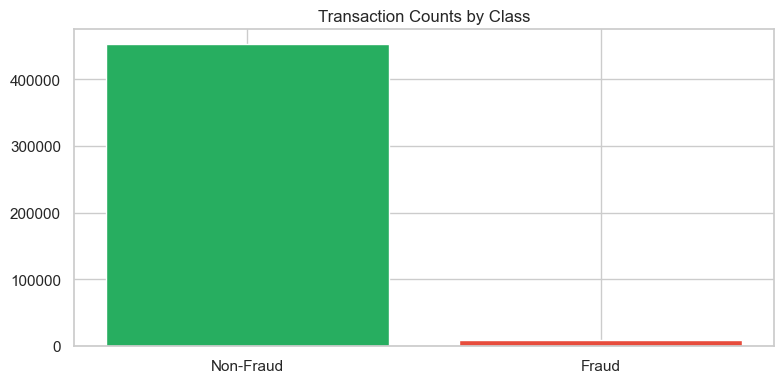

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Non-Fraud", "Fraud"], class_counts.values, color=[COLORS["safe"], COLORS["fraud"]])
ax.set_title("Transaction Counts by Class")
plt.tight_layout()
plt.show()


#### Interpretation of Transaction Counts

The development year contains `452,419` non-fraud transactions and only `8,307` fraud transactions.
That is roughly a `54:1` imbalance in absolute volume. This confirms that the fraud problem is not just
mildly imbalanced; it is dominated by legitimate activity, which is why the later model evaluation must
focus on ranking quality rather than raw accuracy.


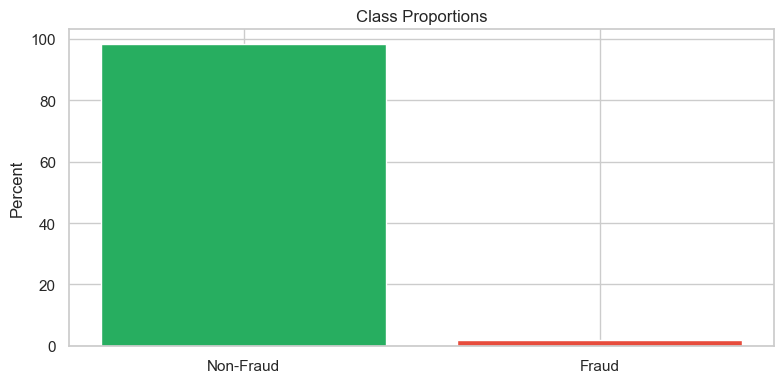

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Non-Fraud", "Fraud"], class_pct.values, color=[COLORS["safe"], COLORS["fraud"]])
ax.set_title("Class Proportions")
ax.set_ylabel("Percent")
plt.tight_layout()
plt.show()


In [33]:
df_plot = df1.copy()
df_plot["amt_log10"] = np.log10(df_plot["amt"].clip(lower=1))
df_plot["is_fraud_str"] = df_plot["is_fraud"].map({0: "Non-Fraud", 1: "Fraud"})
sample_df = df_plot.sample(n=min(50000, len(df_plot)), random_state=SEED)
stats_data = df1.groupby("is_fraud")["amt"].agg(["mean", "median", "std", "max"]).round(2)
stats_data.index = ["Non-Fraud", "Fraud"]


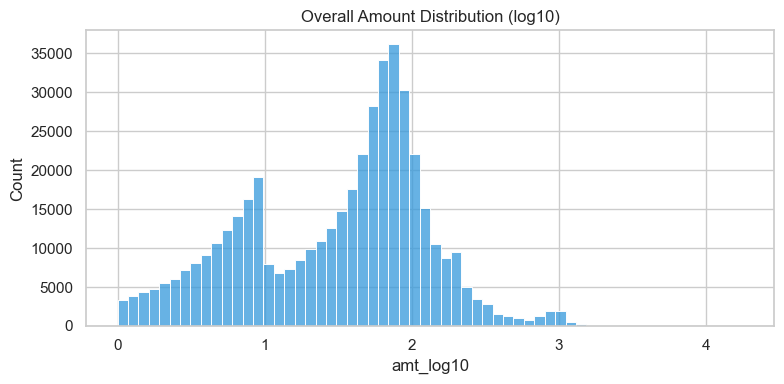

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_plot, x="amt_log10", bins=60, color=COLORS["primary"], ax=ax)
ax.set_title("Overall Amount Distribution (log10)")
plt.tight_layout()
plt.show()


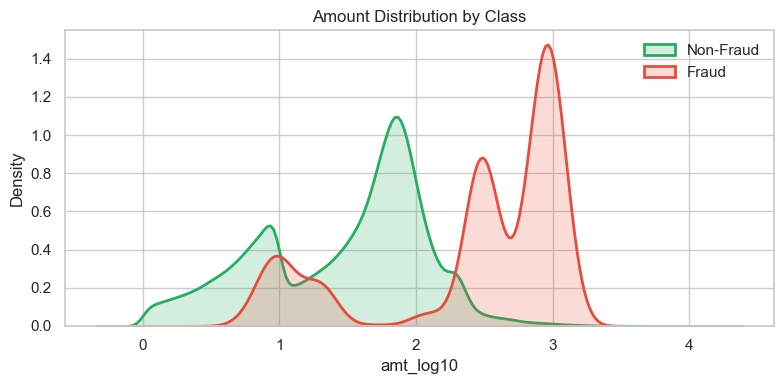

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("Non-Fraud", COLORS["safe"]), ("Fraud", COLORS["fraud"])]:
    subset = df_plot[df_plot["is_fraud_str"] == label]
    sns.kdeplot(data=subset, x="amt_log10", ax=ax, color=color, fill=True, alpha=0.2, linewidth=2, label=label)
ax.set_title("Amount Distribution by Class")
ax.legend()
plt.tight_layout()
plt.show()


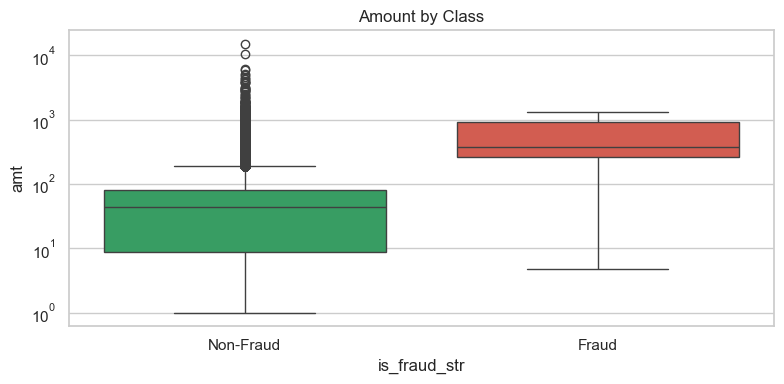

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=sample_df,
    x="is_fraud_str",
    y="amt",
    ax=ax,
    palette={"Non-Fraud": COLORS["safe"], "Fraud": COLORS["fraud"]},
)
ax.set_yscale("log")
ax.set_title("Amount by Class")
plt.tight_layout()
plt.show()


In [37]:
display(stats_data)


,mean,median,std,max
Non-Fraud,66.9000,44.8200,162.2400,"17,726.7000"
Fraud,547.1000,495.8100,390.4900,"1,348.8100"


In [38]:
by_hour = df1.groupby("tx_hour")[TARGET].agg(["mean", "sum", "count"]).reset_index()
by_dow = df1.groupby("tx_dayofweek")[TARGET].agg(["mean", "sum", "count"]).reset_index()
by_month = df1.groupby("tx_month")[TARGET].agg(["mean", "sum", "count"]).reset_index()
dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
by_dow["day_name"] = by_dow["tx_dayofweek"].map(dow_map)


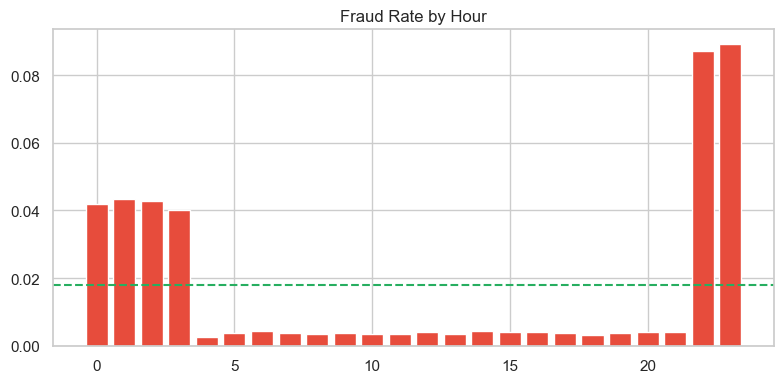

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_hour["tx_hour"], by_hour["mean"], color=COLORS["fraud"])
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Hour")
plt.tight_layout()
plt.show()


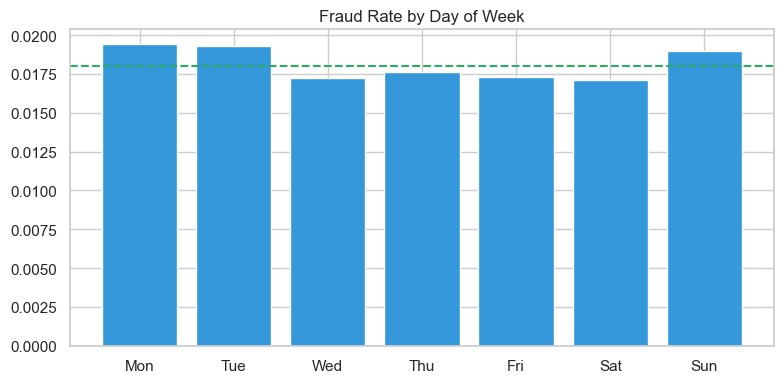

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_dow["day_name"], by_dow["mean"], color=COLORS["primary"])
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Day of Week")
plt.tight_layout()
plt.show()


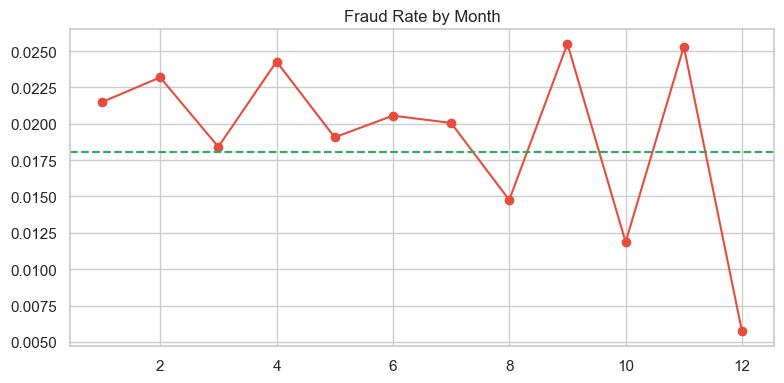

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_month["tx_month"], by_month["mean"], marker="o", color=COLORS["fraud"])
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Month")
plt.tight_layout()
plt.show()


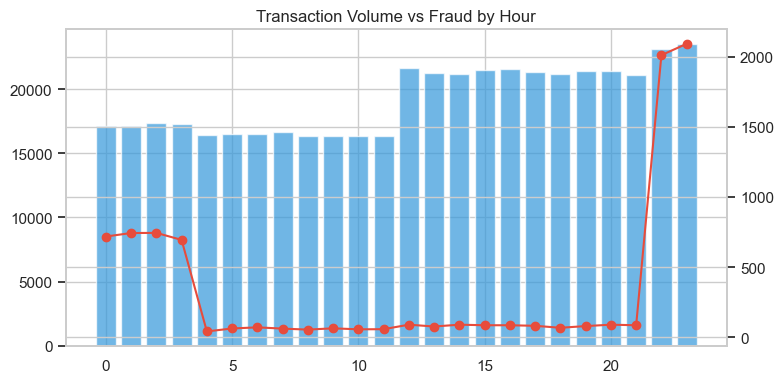

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_hour["tx_hour"], by_hour["count"], color=COLORS["primary"], alpha=0.7)
ax.set_title("Transaction Volume vs Fraud by Hour")
ax_twin = ax.twinx()
ax_twin.plot(by_hour["tx_hour"], by_hour["sum"], color=COLORS["fraud"], marker="o")
plt.tight_layout()
plt.show()


In [43]:
cat_stats = df1.groupby("category")[TARGET].agg(["mean", "sum", "count"]).reset_index()
cat_stats.columns = ["category", "fraud_rate", "fraud_count", "tx_count"]
cat_stats["lift"] = cat_stats["fraud_rate"] / overall_fraud_rate
cat_plot_rate = cat_stats.sort_values("fraud_rate", ascending=True)
cat_plot_vol = cat_stats.sort_values("tx_count", ascending=True)


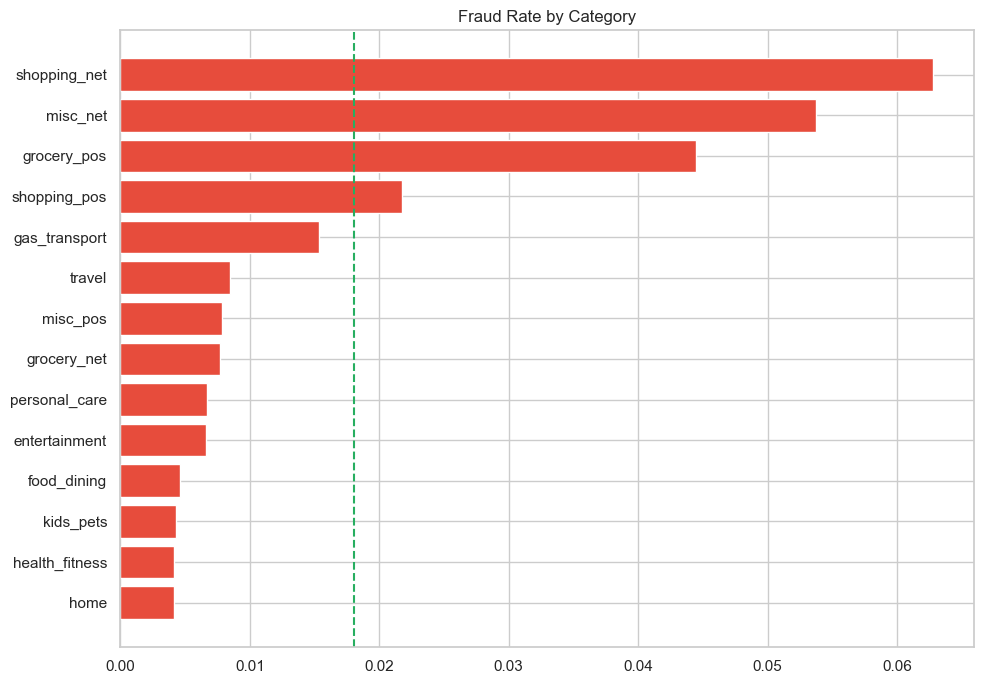

In [44]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cat_plot_rate["category"], cat_plot_rate["fraud_rate"], color=COLORS["fraud"])
ax.axvline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Category")
plt.tight_layout()
plt.show()


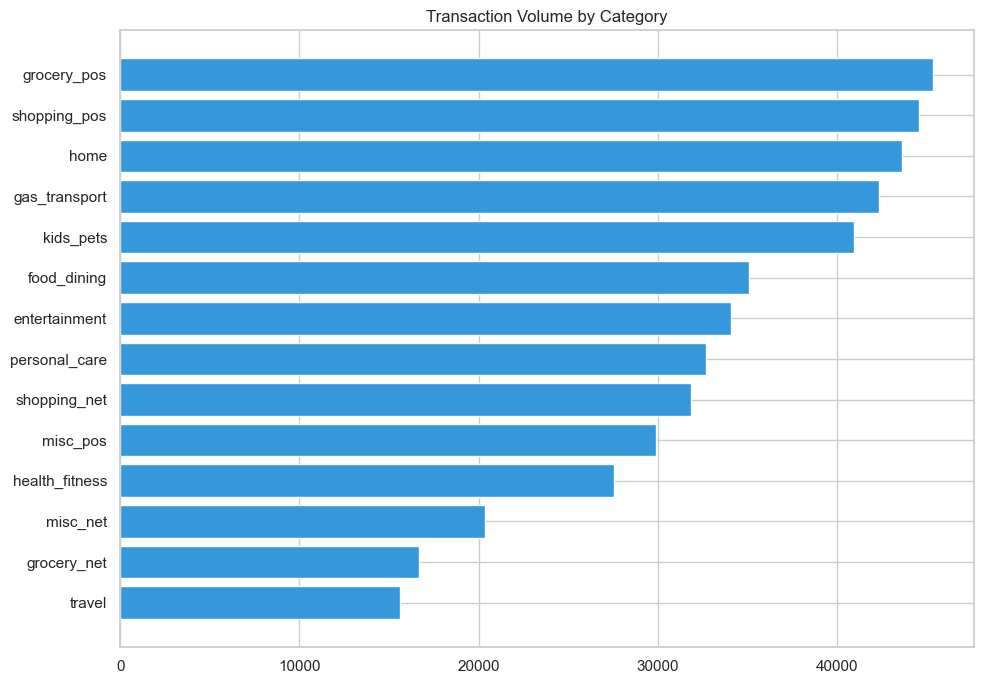

In [45]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cat_plot_vol["category"], cat_plot_vol["tx_count"], color=COLORS["primary"])
ax.set_title("Transaction Volume by Category")
plt.tight_layout()
plt.show()


In [46]:
state_stats = df1.groupby("state")[TARGET].agg(["mean", "sum", "count"]).reset_index()
state_stats.columns = ["state", "fraud_rate", "fraud_count", "tx_count"]
state_stats["lift"] = state_stats["fraud_rate"] / overall_fraud_rate
state_stats = state_stats[state_stats["tx_count"] >= 1000]
top_fraud = state_stats.nlargest(15, "fraud_rate").sort_values("fraud_rate", ascending=True)
top_vol = state_stats.nlargest(15, "fraud_count").sort_values("fraud_count", ascending=True)


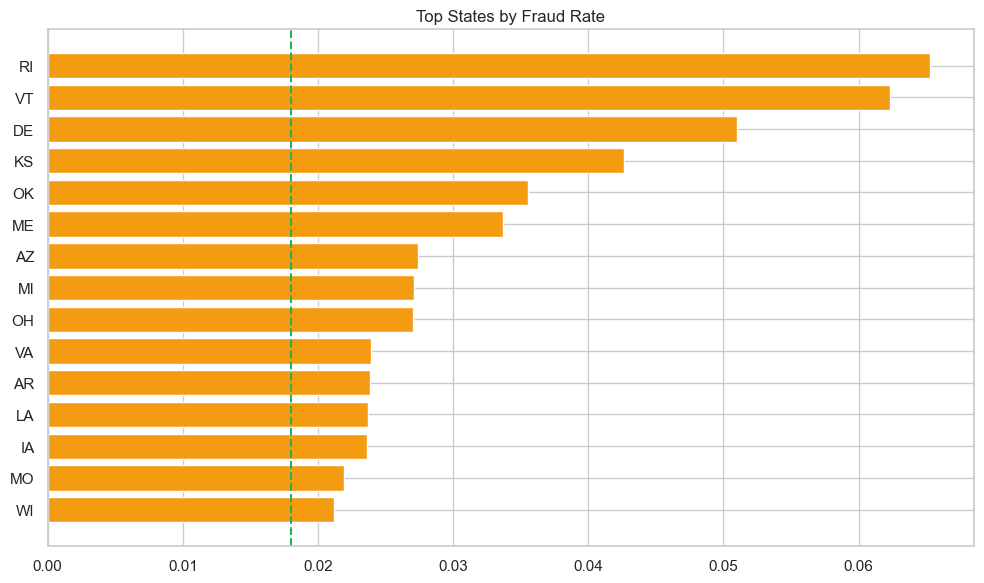

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_fraud["state"], top_fraud["fraud_rate"], color=COLORS["accent"])
ax.axvline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Top States by Fraud Rate")
plt.tight_layout()
plt.show()


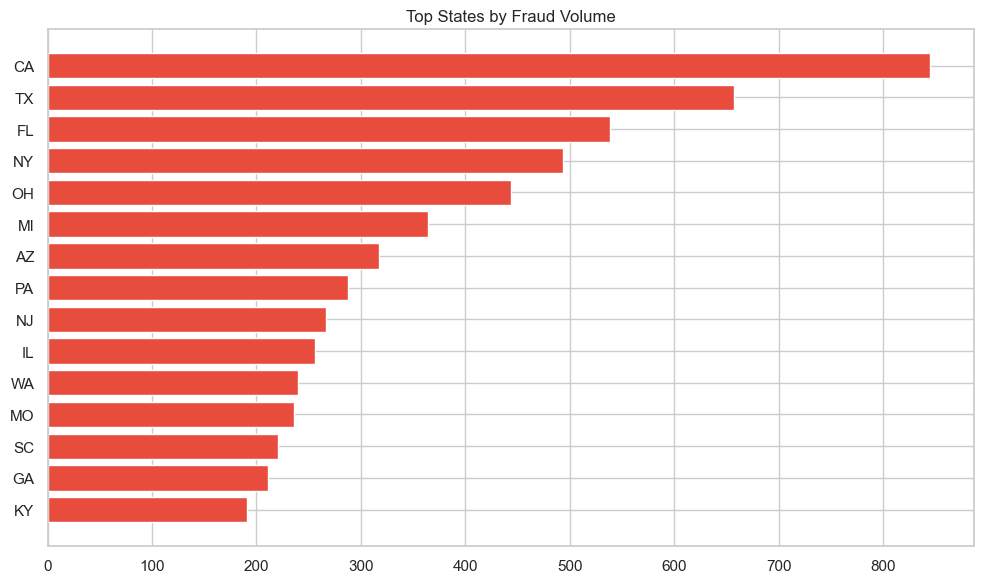

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_vol["state"], top_vol["fraud_count"], color=COLORS["fraud"])
ax.set_title("Top States by Fraud Volume")
plt.tight_layout()
plt.show()


In [49]:
amt_risk = compute_segment_risk(df1, "amt_bucket", min_support=100)


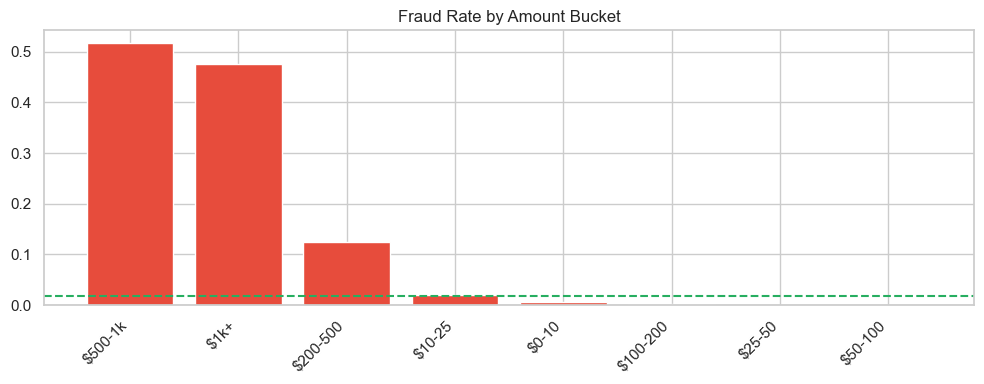

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(amt_risk)), amt_risk["fraud_rate"], color=COLORS["fraud"])
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_xticks(range(len(amt_risk)))
ax.set_xticklabels(amt_risk["amt_bucket"], rotation=45, ha="right")
ax.set_title("Fraud Rate by Amount Bucket")
plt.tight_layout()
plt.show()


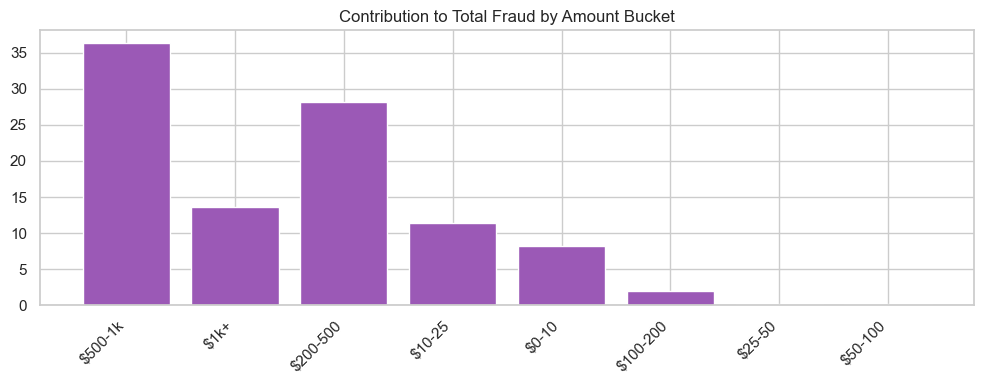

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(amt_risk)), amt_risk["fraud_share_pct"], color=COLORS["secondary"])
ax.set_xticks(range(len(amt_risk)))
ax.set_xticklabels(amt_risk["amt_bucket"], rotation=45, ha="right")
ax.set_title("Contribution to Total Fraud by Amount Bucket")
plt.tight_layout()
plt.show()


In [52]:
interaction = df1.groupby(["category", "amt_bucket"], observed=True).agg(
    tx_count=(TARGET, "size"),
    fraud_count=(TARGET, "sum"),
    fraud_rate=(TARGET, "mean"),
).reset_index()
interaction["lift"] = interaction["fraud_rate"] / overall_fraud_rate
pivot_rate = interaction.pivot(index="category", columns="amt_bucket", values="fraud_rate")
pivot_count = interaction.pivot(index="category", columns="amt_bucket", values="tx_count")
high_risk = interaction[
    (interaction["fraud_rate"] > 0.3) & (interaction["tx_count"] >= 50)
].sort_values("fraud_rate", ascending=False)


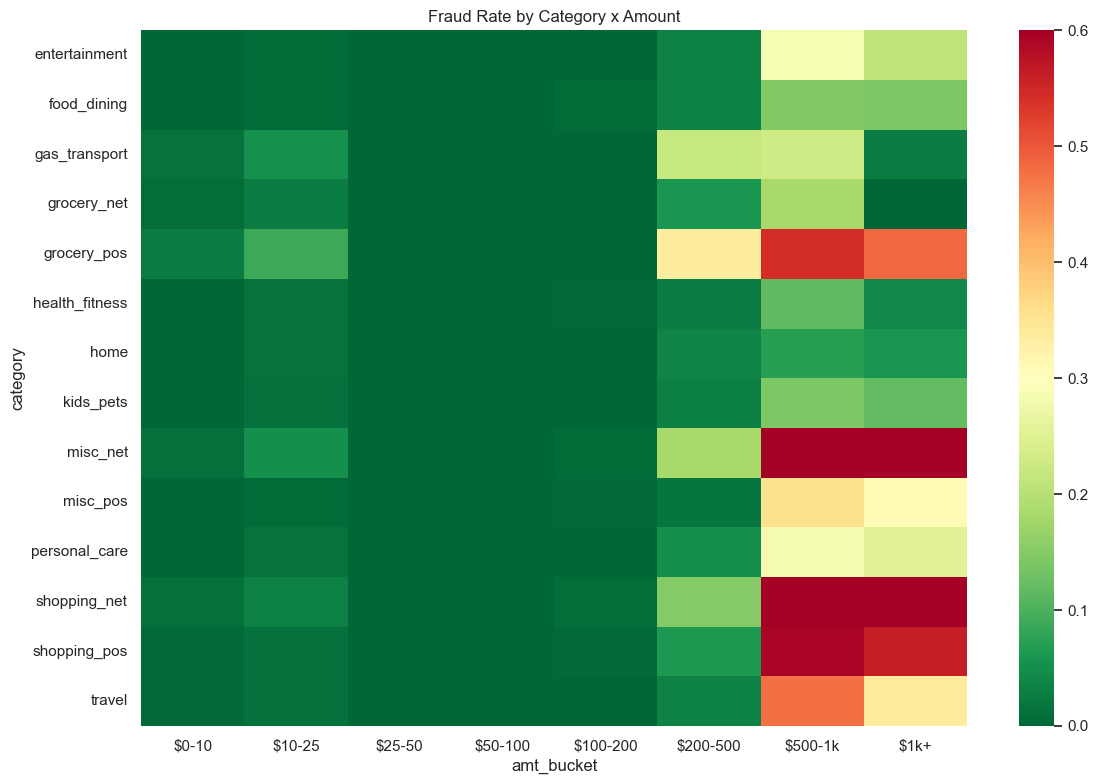

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_rate, annot=False, cmap="RdYlGn_r", ax=ax, vmin=0, vmax=0.6)
ax.set_title("Fraud Rate by Category x Amount")
plt.tight_layout()
plt.show()


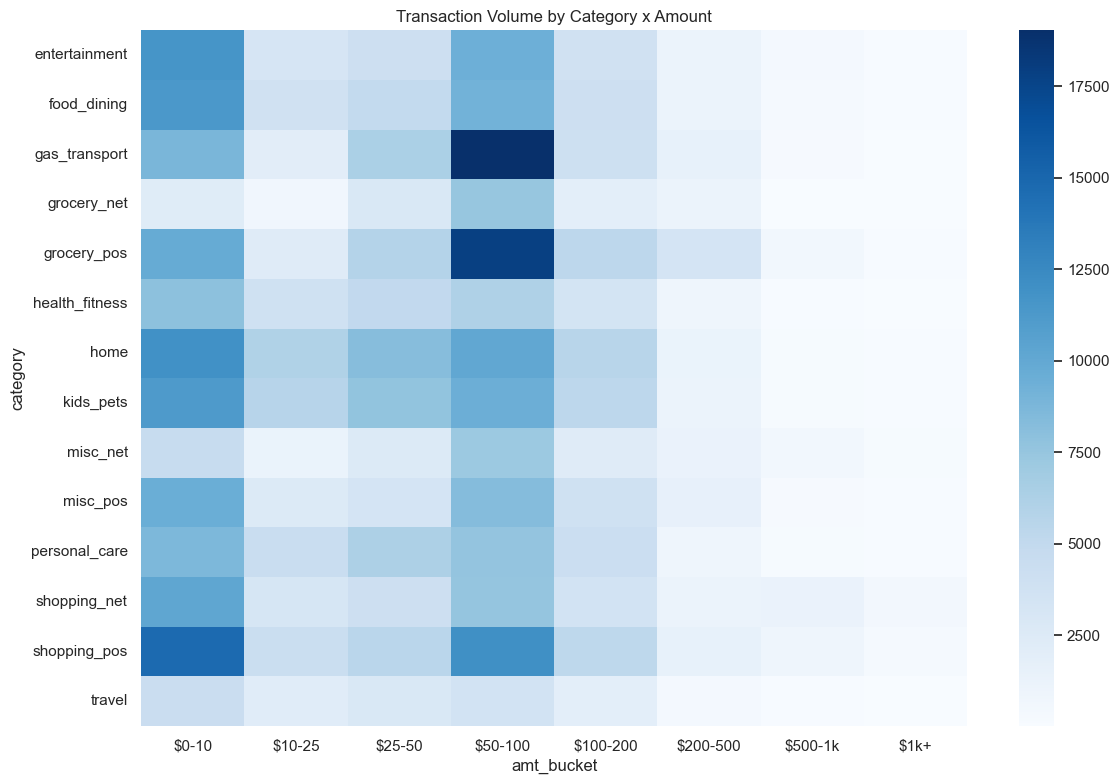

In [54]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_count, annot=False, cmap="Blues", ax=ax)
ax.set_title("Transaction Volume by Category x Amount")
plt.tight_layout()
plt.show()


In [55]:
account_overlap = np.intersect1d(df1["acct_num"].unique(), test_df["acct_num"].unique())
split_report = pd.DataFrame(
    [
        {
            "dataset": "2024 development set",
            "start": df1["tx_datetime"].min(),
            "end": df1["tx_datetime"].max(),
            "accounts": df1["acct_num"].nunique(),
            "fraud_rate": df1[TARGET].mean(),
        },
        {
            "dataset": "2025 hold-out set",
            "start": test_df["tx_datetime"].min(),
            "end": test_df["tx_datetime"].max(),
            "accounts": test_df["acct_num"].nunique(),
            "fraud_rate": test_df[TARGET].mean(),
        },
    ]
)
display(split_report)
print(f"Shared accounts between 2024 and 2025: {len(account_overlap)}")


,dataset,start,end,accounts,fraud_rate
0,2024 development set,2024-01-01 00:00:22+00:00,2024-12-31 23:59:41+00:00,800,0.0180
1,2025 hold-out set,2025-01-01 00:01:37+00:00,2025-05-31 23:57:25+00:00,220,0.0400


Shared accounts between 2024 and 2025: 0


In [56]:
monthly_2024 = df1.groupby("tx_month")[TARGET].mean().reset_index()
prevalence_df = pd.DataFrame(
    {
        "dataset": ["2024 development", "2025 hold-out"],
        "fraud_rate": [df1[TARGET].mean(), test_df[TARGET].mean()],
    }
)


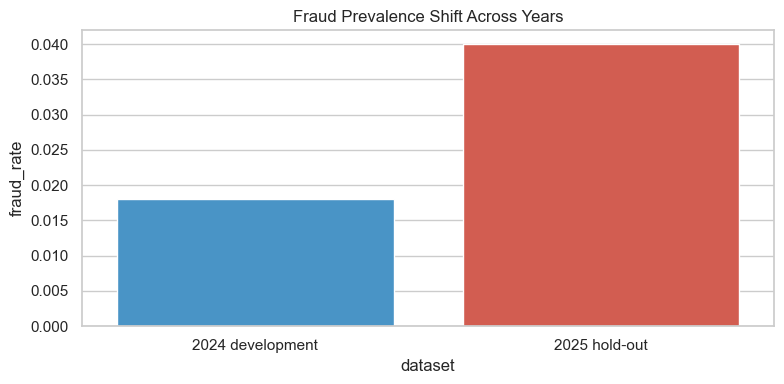

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=prevalence_df, x="dataset", y="fraud_rate", palette=[COLORS["primary"], COLORS["fraud"]], ax=ax)
ax.set_title("Fraud Prevalence Shift Across Years")
plt.tight_layout()
plt.show()


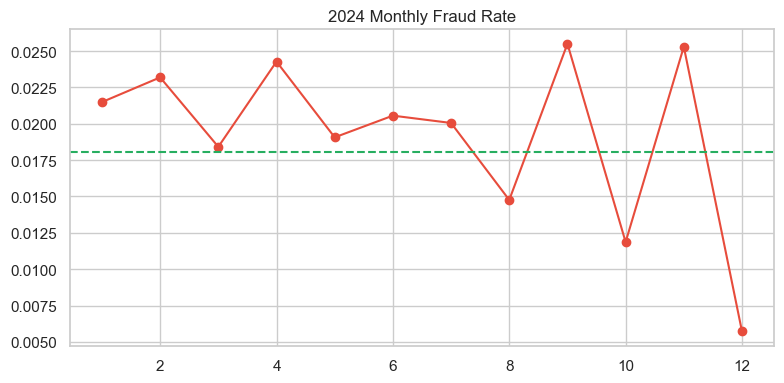

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly_2024["tx_month"], monthly_2024[TARGET], marker="o", color=COLORS["fraud"])
ax.axhline(df1[TARGET].mean(), linestyle="--", color=COLORS["safe"])
ax.set_title("2024 Monthly Fraud Rate")
plt.tight_layout()
plt.show()


In [59]:
channel_stats = df1.groupby("channel_group")[TARGET].agg(["mean", "sum", "count"]).reset_index()
channel_stats.columns = ["channel_group", "fraud_rate", "fraud_count", "tx_count"]
channel_stats["lift"] = channel_stats["fraud_rate"] / overall_fraud_rate
hour_channel_heatmap = df1.pivot_table(index="channel_group", columns="tx_hour", values=TARGET, aggfunc="mean").reindex(index=["online", "in_person", "other"])


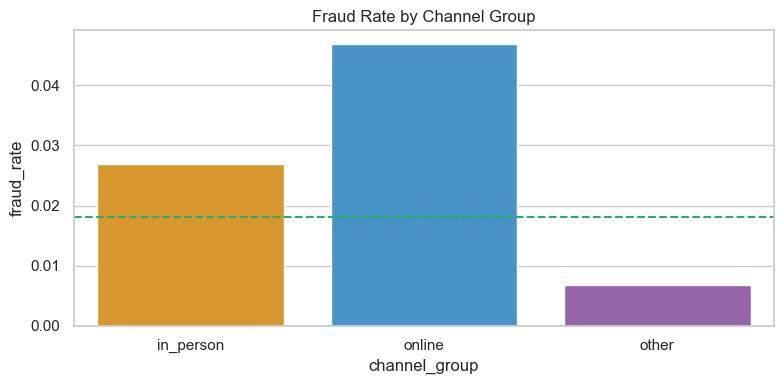

In [60]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=channel_stats,
    x="channel_group",
    y="fraud_rate",
    palette=[COLORS["accent"], COLORS["primary"], COLORS["secondary"]],
    ax=ax,
)
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Channel Group")
plt.tight_layout()
plt.show()


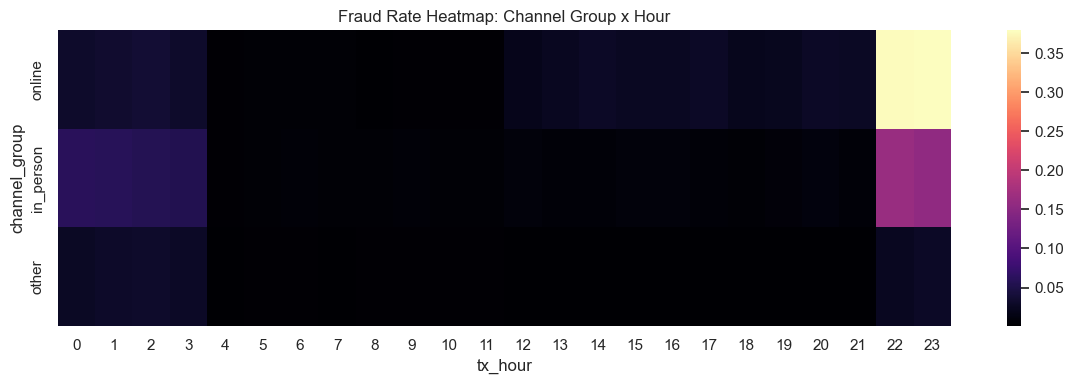

In [61]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(hour_channel_heatmap, cmap="magma", ax=ax)
ax.set_title("Fraud Rate Heatmap: Channel Group x Hour")
plt.tight_layout()
plt.show()


In [62]:
gender_residence = df1.groupby(["gender", "residence"])[TARGET].agg(["mean", "sum", "count"]).reset_index()
gender_residence.columns = ["gender", "residence", "fraud_rate", "fraud_count", "tx_count"]
life_stage_risk = compute_segment_risk(df1, "life_stage", min_support=100)


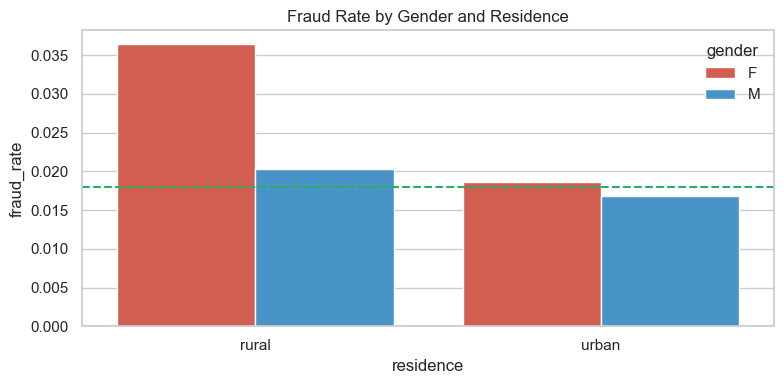

In [63]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=gender_residence,
    x="residence",
    y="fraud_rate",
    hue="gender",
    palette=[COLORS["fraud"], COLORS["primary"]],
    ax=ax,
)
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Gender and Residence")
plt.tight_layout()
plt.show()


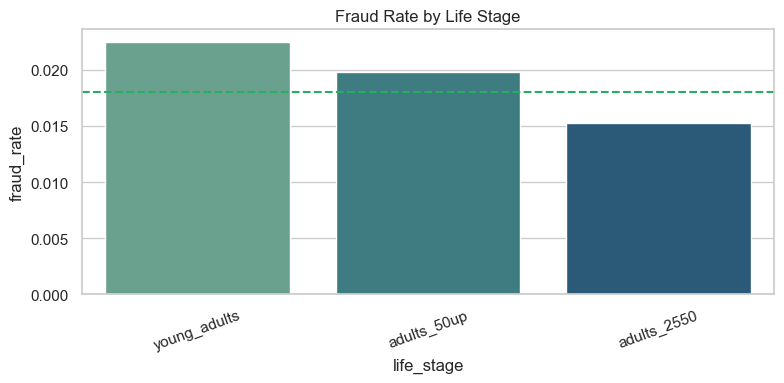

In [64]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=life_stage_risk, x="life_stage", y="fraud_rate", palette="crest", ax=ax)
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Life Stage")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


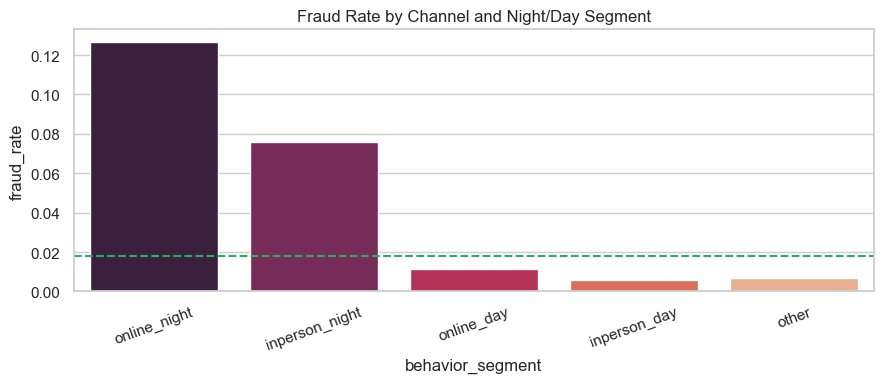

In [65]:
behavior_stats = (
    df1.assign(
        behavior_segment=np.select(
            [
                (df1["channel_group"] == "online") & (df1["is_night"] == 1),
                (df1["channel_group"] == "online") & (df1["is_night"] == 0),
                (df1["channel_group"] == "in_person") & (df1["is_night"] == 1),
                (df1["channel_group"] == "in_person") & (df1["is_night"] == 0),
            ],
            ["online_night", "online_day", "inperson_night", "inperson_day"],
            default="other",
        )
    )
    .groupby("behavior_segment", observed=True)[TARGET]
    .agg(["mean", "sum", "count"])
    .reindex(["online_night", "inperson_night", "online_day", "inperson_day", "other"])
    .reset_index()
)
behavior_stats.columns = ["behavior_segment", "fraud_rate", "fraud_count", "tx_count"]

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=behavior_stats,
    x="behavior_segment",
    y="fraud_rate",
    palette="rocket",
    ax=ax,
)
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Channel and Night/Day Segment")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


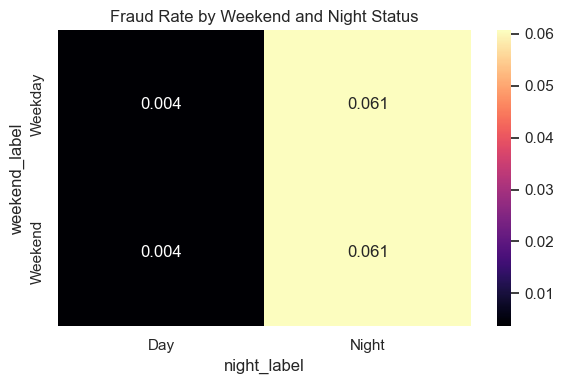

In [66]:
weekend_night = (
    df1.assign(
        weekend_label=np.where(df1["tx_is_weekend"] == 1, "Weekend", "Weekday"),
        night_label=np.where(df1["is_night"] == 1, "Night", "Day"),
    )
    .pivot_table(index="weekend_label", columns="night_label", values=TARGET, aggfunc="mean")
    .reindex(index=["Weekday", "Weekend"], columns=["Day", "Night"])
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(weekend_night, annot=True, fmt=".3f", cmap="magma", ax=ax)
ax.set_title("Fraud Rate by Weekend and Night Status")
plt.tight_layout()
plt.show()


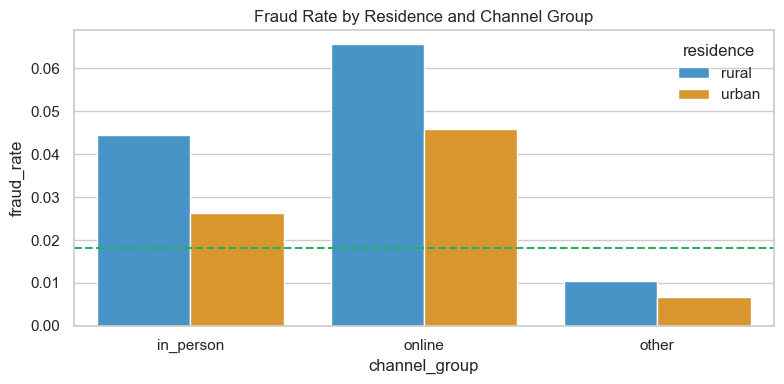

In [67]:
residence_channel = (
    df1.groupby(["channel_group", "residence"], observed=True)[TARGET]
    .agg(["mean", "sum", "count"])
    .reset_index()
)
residence_channel.columns = ["channel_group", "residence", "fraud_rate", "fraud_count", "tx_count"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=residence_channel,
    x="channel_group",
    y="fraud_rate",
    hue="residence",
    palette=[COLORS["primary"], COLORS["accent"]],
    ax=ax,
)
ax.axhline(overall_fraud_rate, linestyle="--", color=COLORS["safe"])
ax.set_title("Fraud Rate by Residence and Channel Group")
plt.tight_layout()
plt.show()


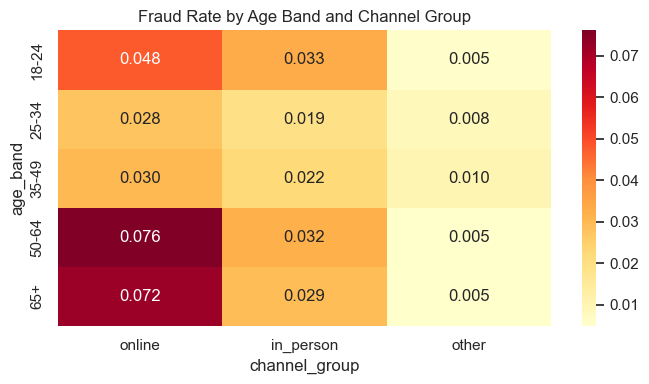

In [68]:
age_channel = (
    df1.groupby(["age_band", "channel_group"], observed=True)[TARGET]
    .agg(["mean", "sum", "count"])
    .reset_index()
)
age_channel.columns = ["age_band", "channel_group", "fraud_rate", "fraud_count", "tx_count"]
age_channel_heatmap = (
    age_channel.pivot(index="age_band", columns="channel_group", values="fraud_rate")
    .reindex(index=["18-24", "25-34", "35-49", "50-64", "65+"], columns=["online", "in_person", "other"])
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(age_channel_heatmap, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
ax.set_title("Fraud Rate by Age Band and Channel Group")
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


TARGET_COL = globals().get("TARGET", "is_fraud")
PALETTE = globals().get(
    "COLORS",
    {
        "safe": "#2E8B57",
        "fraud": "#C44E52",
        "accent": "#4C72B0",
        "neutral": "#6C757D",
    },
)

ANALYSIS_CHART_DIR = Path("thesis_figures") / "data_analysis_v15"
FIGS2_DIR = Path("/Users/nolinjo/Desktop/Thesis/v2/figs2")
for output_dir in (ANALYSIS_CHART_DIR, FIGS2_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)


def _load_analysis_frame_if_needed():
    """Use df1 when the notebook has already run; otherwise load the development CSV directly."""
    if "df1" in globals():
        frame = df1.copy()
    else:
        candidate_paths = [
            Path("all_transactions_2024.csv"),
            Path("../Code/all_transactions_2024.csv"),
            Path("/Users/nolinjo/Desktop/Thesis/Code/all_transactions_2024.csv"),
        ]
        train_path = next((path for path in candidate_paths if path.exists()), None)
        if train_path is None:
            raise FileNotFoundError(
                "Could not locate all_transactions_2024.csv. Run the notebook from the project root or update candidate_paths."
            )
        frame = pd.read_csv(train_path, sep="|")

    if "tx_datetime" not in frame.columns and {"trans_date", "trans_time"}.issubset(frame.columns):
        frame["tx_datetime"] = pd.to_datetime(
            frame["trans_date"].astype(str) + " " + frame["trans_time"].astype(str),
            errors="coerce",
        )
    if "dob" in frame.columns:
        frame["dob"] = pd.to_datetime(frame["dob"], errors="coerce")
        if "age_years" not in frame.columns:
            if "tx_datetime" in frame.columns:
                frame["age_years"] = ((frame["tx_datetime"] - frame["dob"]).dt.days / 365.25).clip(lower=18, upper=100)
            else:
                frame["age_years"] = (2024 - frame["dob"].dt.year).clip(lower=18, upper=100)
        if "age" not in frame.columns:
            frame["age"] = frame["age_years"]
    if "age_years" in frame.columns:
        frame["age_band"] = pd.cut(
            frame["age_years"],
            bins=[18, 25, 35, 50, 65, 101],
            labels=["18-24", "25-34", "35-49", "50-64", "65+"],
            right=False,
        )
    elif "age" in frame.columns and "age_band" not in frame.columns:
        frame["age_band"] = pd.cut(
            frame["age"],
            bins=[18, 25, 35, 50, 65, 101],
            labels=["18-24", "25-34", "35-49", "50-64", "65+"],
            right=False,
        )
    if "residence" not in frame.columns and "profile" in frame.columns:
        frame["residence"] = frame["profile"].astype(str).str.extract(r"(urban|rural)", expand=False).fillna("unknown")
    if "residence_label" not in frame.columns:
        if "residence" in frame.columns:
            frame["residence_label"] = frame["residence"].astype(str).str.title()
        elif "is_rural" in frame.columns:
            frame["residence_label"] = np.where(frame["is_rural"] == 1, "Rural", "Urban")
    if "life_stage" not in frame.columns and "profile" in frame.columns:
        frame["life_stage"] = frame["profile"].astype(str).str.extract(
            r"^(young_adults|adults_2550|adults_50up)", expand=False
        ).fillna("unknown")
    if "channel_group" not in frame.columns and "category" in frame.columns:
        frame["channel_group"] = np.where(
            frame["category"].astype(str).str.endswith("_net"),
            "online",
            np.where(frame["category"].astype(str).str.endswith("_pos"), "in_person", "other"),
        )
    if "gender" in frame.columns and "gender_label" not in frame.columns:
        frame["gender_label"] = (
            frame["gender"].map({"M": "Male", "F": "Female"}).fillna(frame["gender"].astype(str))
        )
    return frame


analysis_df = _load_analysis_frame_if_needed()
analysis_df["class_label"] = analysis_df[TARGET_COL].map({0: "Non-Fraud", 1: "Fraud"})
class_colors = {"Non-Fraud": PALETTE["safe"], "Fraud": PALETTE["fraud"]}


def annotate_bars(ax, formatter):
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height) or height <= 0:
            continue
        ax.annotate(
            formatter(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
        )


def save_current_figure(filename):
    primary_path = ANALYSIS_CHART_DIR / filename
    secondary_path = FIGS2_DIR / filename
    plt.savefig(primary_path, dpi=160, bbox_inches="tight")
    if secondary_path.resolve() != primary_path.resolve():
        plt.savefig(secondary_path, dpi=160, bbox_inches="tight")
    print(f"Saved {primary_path}")
    print(f"Saved {secondary_path}")




Saved thesis_figures/data_analysis_v15/chart01_demographic_residence_context.png
Saved /Users/nolinjo/Desktop/Thesis/v2/figs2/chart01_demographic_residence_context.png


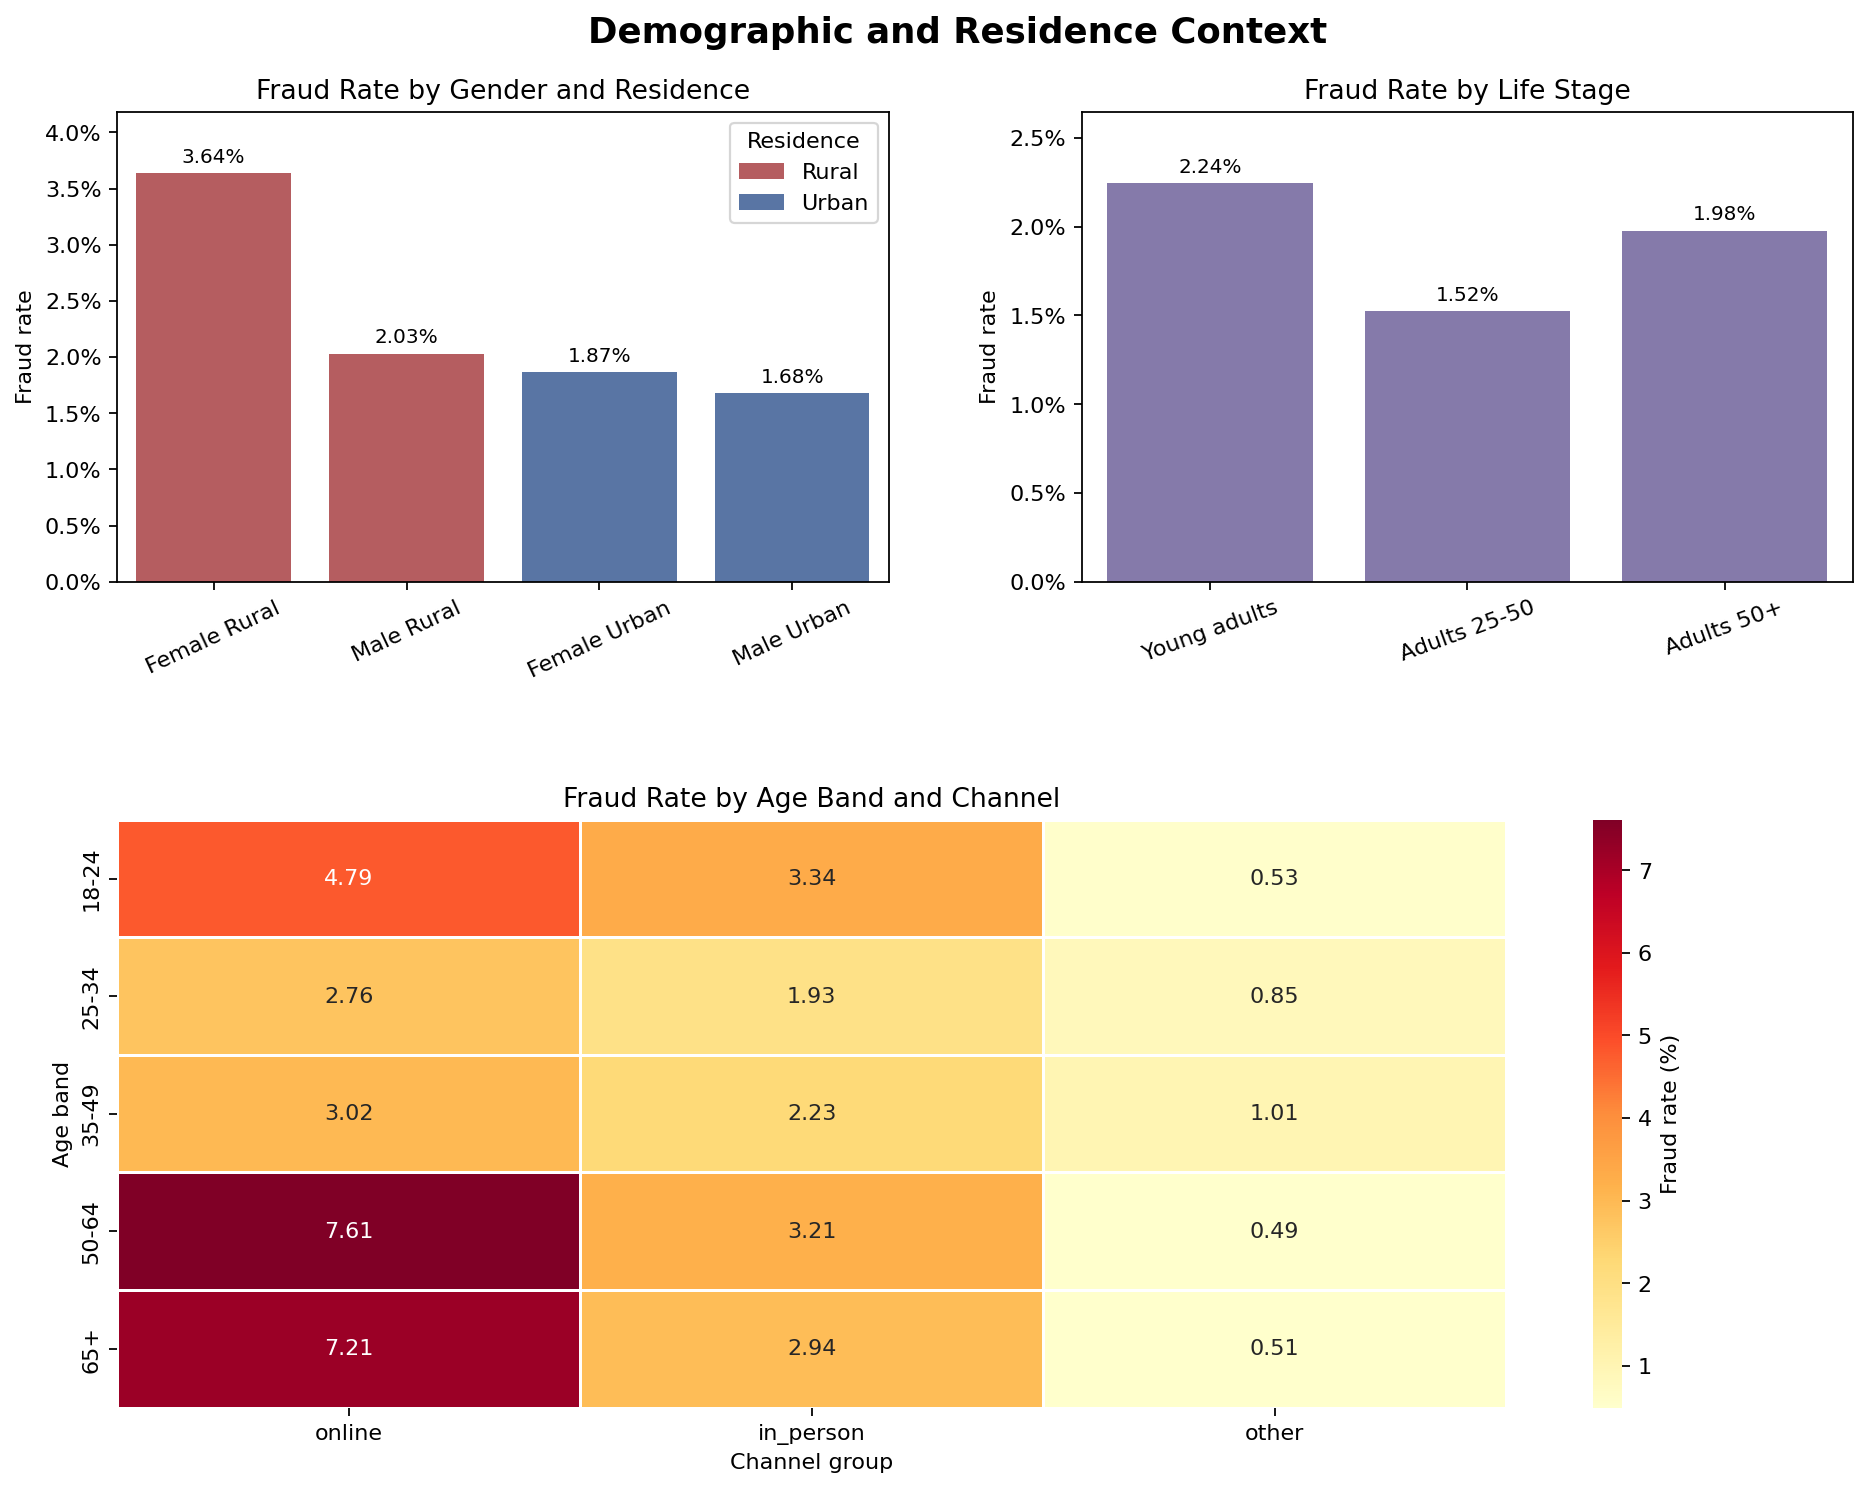

In [ ]:
# 1. Demographic and residence context
fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.25], hspace=0.45, wspace=0.25)
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[1, :])]

gender_residence = (
    analysis_df.groupby(["gender_label", "residence_label"], observed=True)[TARGET_COL]
    .agg(fraud_rate="mean", tx_count="count")
    .reset_index()
)
gender_residence["segment"] = gender_residence["gender_label"] + " " + gender_residence["residence_label"]
gender_residence["fraud_rate_pct"] = gender_residence["fraud_rate"] * 100
segment_order = ["Female Rural", "Male Rural", "Female Urban", "Male Urban"]
gender_residence["segment"] = pd.Categorical(gender_residence["segment"], categories=segment_order, ordered=True)
gender_residence = gender_residence.sort_values("segment")

sns.barplot(
    data=gender_residence,
    x="segment",
    y="fraud_rate_pct",
    hue="residence_label",
    palette={"Rural": PALETTE["fraud"], "Urban": PALETTE["accent"]},
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("Fraud Rate by Gender and Residence")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraud rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
axes[0].set_ylim(0, gender_residence["fraud_rate_pct"].max() * 1.15)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Residence")
annotate_bars(axes[0], lambda x: f"{x:.2f}%")

life_stage_labels = {
    "young_adults": "Young adults",
    "adults_2550": "Adults 25-50",
    "adults_50up": "Adults 50+",
}
life_stage_rates = (
    analysis_df.assign(life_stage_label=analysis_df["life_stage"].map(life_stage_labels).fillna(analysis_df["life_stage"]))
    .groupby("life_stage_label", observed=True)[TARGET_COL]
    .mean()
    .mul(100)
    .reindex(["Young adults", "Adults 25-50", "Adults 50+"])
    .reset_index(name="fraud_rate_pct")
)
sns.barplot(
    data=life_stage_rates,
    x="life_stage_label",
    y="fraud_rate_pct",
    color="#8172B2",
    ax=axes[1],
)
axes[1].set_title("Fraud Rate by Life Stage")
axes[1].set_xlabel("")
axes[1].set_ylabel("Fraud rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
axes[1].set_ylim(0, life_stage_rates["fraud_rate_pct"].max() * 1.18)
axes[1].tick_params(axis="x", rotation=20)
annotate_bars(axes[1], lambda x: f"{x:.2f}%")

age_channel_rates = (
    analysis_df.groupby(["age_band", "channel_group"], observed=True)[TARGET_COL]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=["18-24", "25-34", "35-49", "50-64", "65+"], columns=["online", "in_person", "other"])
)
sns.heatmap(
    age_channel_rates,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Fraud rate (%)"},
    linewidths=0.5,
    ax=axes[2],
)
axes[2].set_title("Fraud Rate by Age Band and Channel")
axes[2].set_xlabel("Channel group")
axes[2].set_ylabel("Age band")

fig.suptitle("Demographic and Residence Context", fontsize=16, fontweight="bold", y=0.98)
fig.subplots_adjust(top=0.92)
save_current_figure("chart01_demographic_residence_context.png")
plt.show()




Saved thesis_figures/data_analysis_v15/chart02_transaction_counts_by_class.png
Saved /Users/nolinjo/Desktop/Thesis/v2/figs2/chart02_transaction_counts_by_class.png


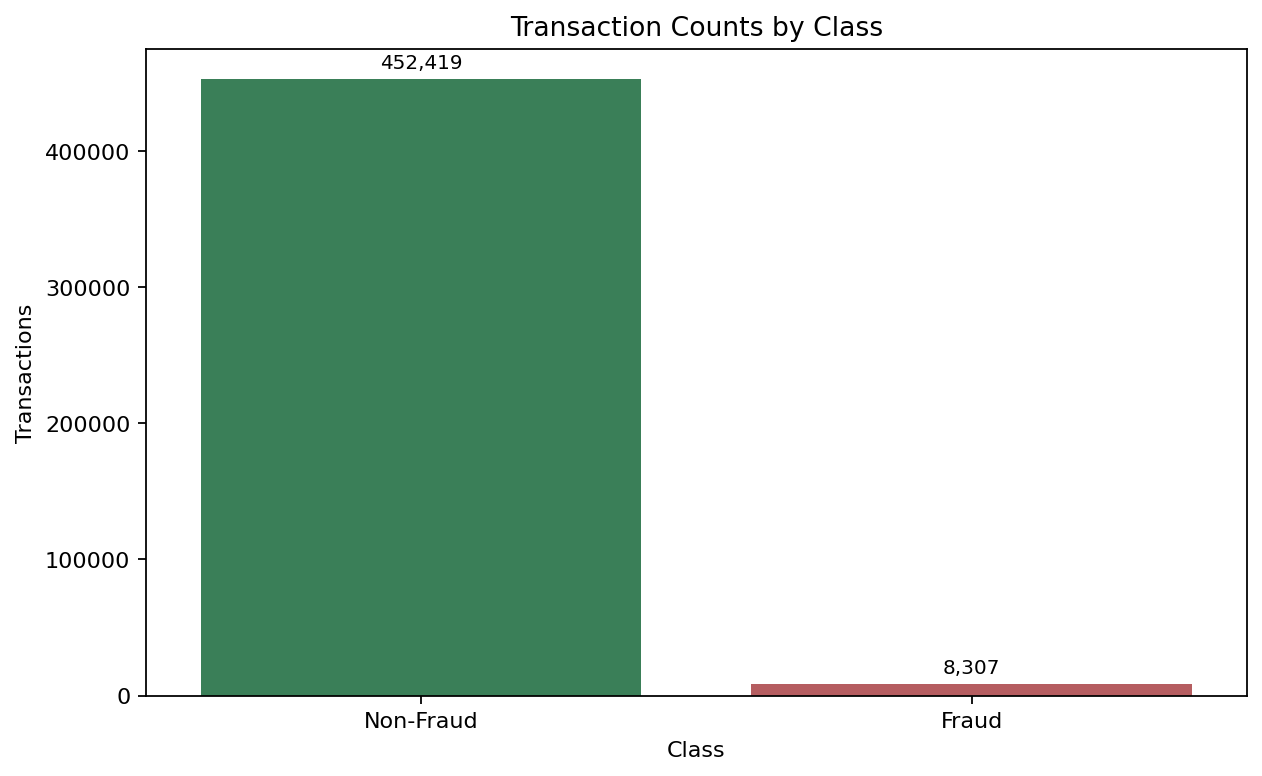

In [ ]:
# 2. Transaction counts by class
class_counts = analysis_df["class_label"].value_counts().reindex(["Non-Fraud", "Fraud"])
class_count_plot = class_counts.rename_axis("Class").reset_index(name="Transactions")
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=class_count_plot,
    x="Class",
    y="Transactions",
    hue="Class",
    palette=class_colors,
    legend=False,
)
ax.set_title("Transaction Counts by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Transactions")
annotate_bars(ax, lambda x: f"{x:,.0f}")
plt.tight_layout()
save_current_figure("chart02_transaction_counts_by_class.png")
plt.show()




Saved thesis_figures/data_analysis_v15/chart03_fraud_proportion_by_class.png
Saved /Users/nolinjo/Desktop/Thesis/v2/figs2/chart03_fraud_proportion_by_class.png


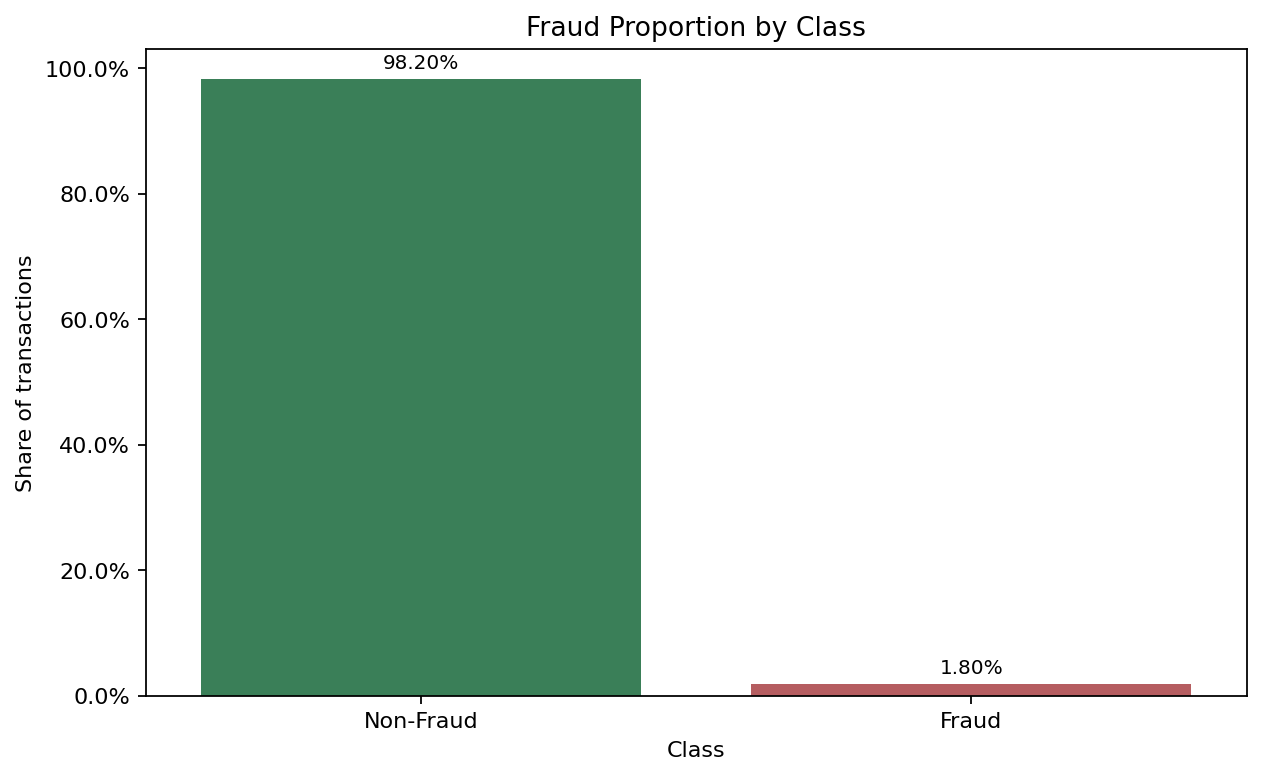

In [ ]:
# 3. Fraud proportion by class
class_counts = analysis_df["class_label"].value_counts().reindex(["Non-Fraud", "Fraud"])
class_proportions = class_counts / class_counts.sum()
class_proportion_plot = class_proportions.rename_axis("Class").reset_index(name="Share")
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=class_proportion_plot,
    x="Class",
    y="Share",
    hue="Class",
    palette=class_colors,
    legend=False,
)
ax.set_title("Fraud Proportion by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Share of transactions")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
annotate_bars(ax, lambda x: f"{x:.2%}")
plt.tight_layout()
save_current_figure("chart03_fraud_proportion_by_class.png")
plt.show()




Saved thesis_figures/data_analysis_v15/chart04_overall_amount_distribution.png
Saved /Users/nolinjo/Desktop/Thesis/v2/figs2/chart04_overall_amount_distribution.png


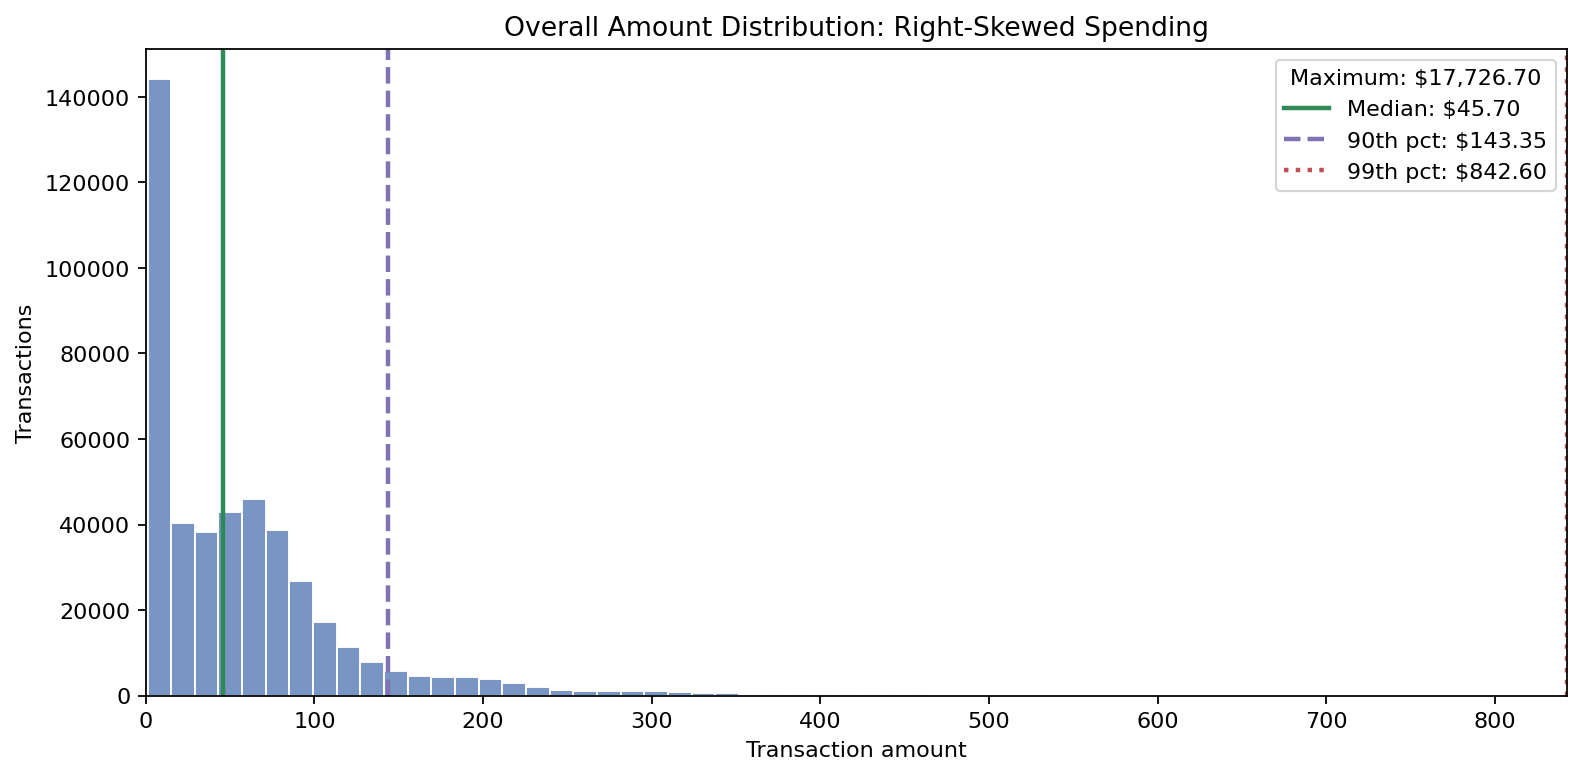

In [ ]:
# 4. Overall amount distribution
amount_median = analysis_df["amt"].median()
amount_p90 = analysis_df["amt"].quantile(0.90)
amount_cap = analysis_df["amt"].quantile(0.99)
amount_max = analysis_df["amt"].max()

plt.figure(figsize=(10, 5))
ax = sns.histplot(
    analysis_df.loc[analysis_df["amt"] <= amount_cap, "amt"],
    bins=60,
    color=PALETTE["accent"],
    edgecolor="white",
)
reference_lines = [
    (amount_median, f"Median: ${amount_median:,.2f}", PALETTE["safe"], "-"),
    (amount_p90, f"90th pct: ${amount_p90:,.2f}", "#8172B2", "--"),
    (amount_cap, f"99th pct: ${amount_cap:,.2f}", PALETTE["fraud"], ":"),
]
for value, label, color, linestyle in reference_lines:
    ax.axvline(value, color=color, linestyle=linestyle, linewidth=2, label=label)
ax.set_title("Overall Amount Distribution: Right-Skewed Spending")
ax.set_xlabel("Transaction amount")
ax.set_ylabel("Transactions")
ax.set_xlim(0, amount_cap)
ax.legend(title=f"Maximum: ${amount_max:,.2f}", loc="upper right")
plt.tight_layout()
save_current_figure("chart04_overall_amount_distribution.png")
plt.show()




Saved thesis_figures/data_analysis_v15/chart05_amount_distribution_by_fraud_status.png
Saved /Users/nolinjo/Desktop/Thesis/v2/figs2/chart05_amount_distribution_by_fraud_status.png


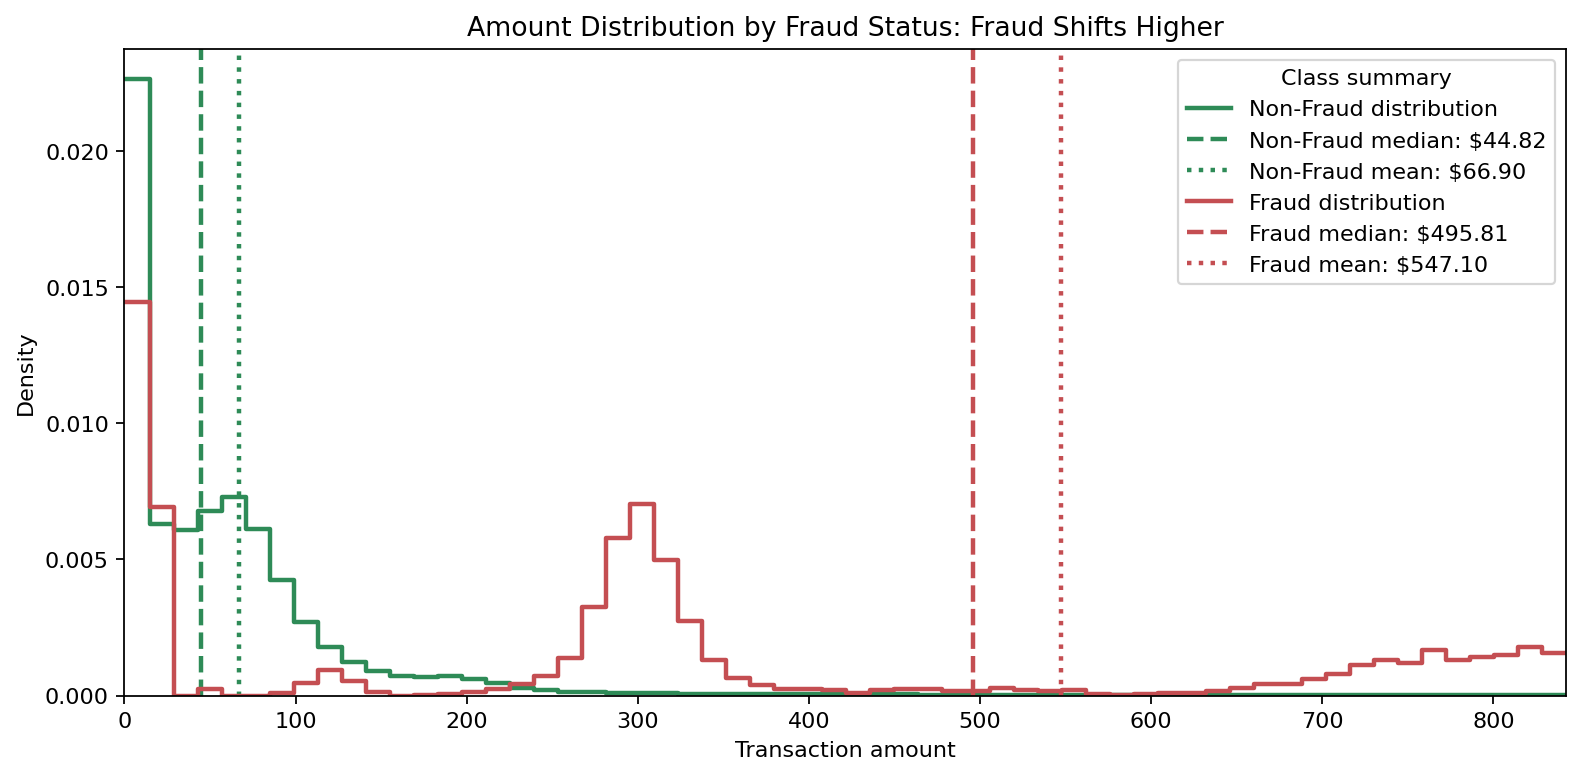

In [ ]:
# 5. Amount distribution by fraud status
amount_cap = analysis_df["amt"].quantile(0.99)
status_stats = analysis_df.groupby("class_label")["amt"].agg(["mean", "median"])

plt.figure(figsize=(10, 5))
for label in ["Non-Fraud", "Fraud"]:
    values = analysis_df.loc[
        (analysis_df["class_label"] == label) & (analysis_df["amt"] <= amount_cap),
        "amt",
    ]
    sns.histplot(
        values,
        bins=60,
        stat="density",
        element="step",
        fill=False,
        linewidth=2,
        color=class_colors[label],
        label=f"{label} distribution",
    )
    median_value = status_stats.loc[label, "median"]
    mean_value = status_stats.loc[label, "mean"]
    ax = plt.gca()
    ax.axvline(
        median_value,
        color=class_colors[label],
        linestyle="--",
        linewidth=2,
        label=f"{label} median: ${median_value:,.2f}",
    )
    ax.axvline(
        mean_value,
        color=class_colors[label],
        linestyle=":",
        linewidth=2,
        label=f"{label} mean: ${mean_value:,.2f}",
    )
ax = plt.gca()
ax.set_title("Amount Distribution by Fraud Status: Fraud Shifts Higher")
ax.set_xlabel("Transaction amount")
ax.set_ylabel("Density")
ax.set_xlim(0, amount_cap)
ax.legend(title="Class summary", loc="upper right")
plt.tight_layout()
save_current_figure("chart05_amount_distribution_by_fraud_status.png")
plt.show()


#### EDA Summary

Based on the EDA, we see that large transactions, late-night activity, online transactions and certain types of merchants pose a higher risk for fraud.
The analysis also shows some variables are more useful when used with other variables. channel and night activity reinforce each other, weekend status adds little once night activity is controlled for, rural transactions are riskier within each channel, and age becomes more meaningful when considered in conjunction with channel.

## 6. Machine Learning Framework and Model Development

In this section machine learning models will be developed, this section defines the features to be used, splits the training data chronologically into train and validation sets, and compares different types of models using the same preprocessing and evaluation rules.

This allows fair comparison of models. All models use the same information and only the best model is selected based on the validation performance. The 2025 data is held out so that it is only used at the end for final testing.

### 6.1 Shared Modeling Protocol

This part prepares the final data structure used for modelling. It creates the modelling table, splits the training data chronologically into 80% training data and 20% validation data, and prepares the holdout test dataset for final testing.


In [70]:
train_model = df1.sort_values("tx_datetime").reset_index(drop=True)

numeric_features = [
    "amt",
    "amt_log",
    "age_years",
    "lat",
    "long",
    "city_pop_log",
    "merchant_distance_km",
    "tx_hour",
    "tx_dayofweek",
    "tx_month",
    "tx_week",
    "tx_is_weekend",
    "is_night",
    "hour_sin",
    "hour_cos",
    "online_flag",
    "high_amt_flag",
    "night_online",
]
categorical_features = ["gender", "state", "category", "residence", "life_stage"]
feature_columns = numeric_features + categorical_features

split_idx = int(len(train_model) * 0.80)
train_split = train_model.iloc[:split_idx].copy()
valid_split = train_model.iloc[split_idx:].copy()

X_train = train_split[feature_columns]
y_train = train_split[TARGET].astype(int).to_numpy()
X_valid = valid_split[feature_columns]
y_valid = valid_split[TARGET].astype(int).to_numpy()
X_test = test_df[feature_columns]
y_test = test_df[TARGET].astype(int).to_numpy()


In [71]:
def make_linear_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), categorical_features),
        ]
    )


def make_tree_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), categorical_features),
        ]
    )


In [72]:
def expected_calibration_error(y_true, probs, n_bins=10):
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    bins = np.linspace(0, 1, n_bins + 1)
    bucket_ids = np.digitize(probs, bins[1:-1], right=True)
    ece = 0.0
    for bucket in range(n_bins):
        mask = bucket_ids == bucket
        if mask.any():
            ece += abs(y_true[mask].mean() - probs[mask].mean()) * mask.mean()
    return ece


def build_pipeline(estimator, model_type):
    preprocessor = make_linear_preprocessor() if model_type == "linear" else make_tree_preprocessor()
    return Pipeline([("preprocessor", preprocessor), ("model", clone(estimator))])


def get_scores(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1], "probability"
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X), "decision"
    return fitted_model.predict(X).astype(float), "label"


In [73]:
def evaluate_single_config(config_name, estimator, model_type):
    pipeline = build_pipeline(estimator, model_type)
    pipeline.fit(X_train, y_train)
    valid_scores, score_type = get_scores(pipeline, X_valid)
    test_scores, _ = get_scores(pipeline, X_test)

    row = {
        "config": config_name,
        "score_type": score_type,
        "valid_pr_auc": average_precision_score(y_valid, valid_scores),
        "valid_roc_auc": roc_auc_score(y_valid, valid_scores),
        "test_pr_auc": average_precision_score(y_test, test_scores),
        "test_roc_auc": roc_auc_score(y_test, test_scores),
    }
    if score_type == "probability":
        row["valid_brier"] = brier_score_loss(y_valid, valid_scores)
        row["valid_ece"] = expected_calibration_error(y_valid, valid_scores)
        row["test_brier"] = brier_score_loss(y_test, test_scores)
        row["test_ece"] = expected_calibration_error(y_test, test_scores)
    else:
        row["valid_brier"] = np.nan
        row["valid_ece"] = np.nan
        row["test_brier"] = np.nan
        row["test_ece"] = np.nan
    return row, pipeline, valid_scores, test_scores


family_best_rows = []
family_best_models = {}
family_best_scores = {}
family_best_specs = {}
family_config_tables = {}


### 6.4 Dummy Baseline

The dummy classifier will be developed on this part. The model does not learn patterns from the data. It only predicts based on the overall fraud rate. It is included as the minimum benchmark. Any useful machine-learning model should perform better than this baseline.


In [74]:
dummy_configs = {"prior": DummyClassifier(strategy="prior")}
dummy_rows = []
for config_name, estimator in dummy_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="linear")
    dummy_rows.append(row)
    family_best_models["Dummy"] = pipeline
    family_best_scores["Dummy"] = {"valid": valid_scores, "test": test_scores}
    family_best_specs["Dummy"] = {"model_type": "linear", "estimator": estimator, "config": config_name}

dummy_table = pd.DataFrame(dummy_rows)
family_config_tables["Dummy"] = dummy_table
dummy_best = dummy_table.iloc[0].copy()
dummy_best["model"] = "Dummy"
dummy_best["best_config"] = "prior"
family_best_rows.append(dummy_best)
display(dummy_table)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,prior,probability,0.0102,0.5000,0.0400,0.5000,0.0102,0.0097,0.0388,0.0200


### 6.5 Logistic Regression

In this part the logistic regression will be developed. The model learns a simple linear relationship between the input features and the fraud label. Numeric features are standardized, and categorical features are converted into one-hot encoded columns.


In [75]:
logistic_configs = {
    "plain_c1.0": LogisticRegression(max_iter=1000, random_state=SEED),
    "balanced_c1.0": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "plain_c0.5": LogisticRegression(max_iter=1000, C=0.5, random_state=SEED),
}
logistic_rows = []
logistic_store = {}
for config_name, estimator in logistic_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="linear")
    logistic_rows.append(row)
    logistic_store[config_name] = (pipeline, valid_scores, test_scores)

logistic_table = pd.DataFrame(logistic_rows).sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
family_config_tables["LogisticRegression"] = logistic_table
display(logistic_table)

best_config = logistic_table.iloc[0]["config"]
best_pipeline, best_valid_scores, best_test_scores = logistic_store[best_config]
family_best_models["LogisticRegression"] = best_pipeline
family_best_scores["LogisticRegression"] = {"valid": best_valid_scores, "test": best_test_scores}
family_best_specs["LogisticRegression"] = {"model_type": "linear", "estimator": logistic_configs[best_config], "config": best_config}
best_row = logistic_table.iloc[0].copy()
best_row["model"] = "LogisticRegression"
best_row["best_config"] = best_config
family_best_rows.append(best_row)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,plain_c0.5,probability,0.0250,0.7367,0.2403,0.8917,0.2832,0.3604,0.0442,0.0385
1,plain_c1.0,probability,0.0180,0.6835,0.1922,0.8799,0.3551,0.4139,0.0566,0.0527
2,balanced_c1.0,probability,0.0115,0.5319,0.1371,0.8312,0.5816,0.6362,0.1439,0.1803


### 6.6 SGDClassifier

This section provides the developement of SGDClassifier. This model learns a linear fraud prediction rule using small step-by-step updates during training. This makes it useful for large datasets and many sparse features, especially after one-hot encoding.


In [76]:
sgd_configs = {
    "alpha_1e-4": SGDClassifier(loss="log_loss", penalty="l2", alpha=1e-4, class_weight="balanced", max_iter=2000, random_state=SEED),
    "alpha_5e-5": SGDClassifier(loss="log_loss", penalty="l2", alpha=5e-5, class_weight="balanced", max_iter=2000, random_state=SEED),
    "elasticnet": SGDClassifier(loss="log_loss", penalty="elasticnet", alpha=1e-4, l1_ratio=0.15, class_weight="balanced", max_iter=2000, random_state=SEED),
}
sgd_rows = []
sgd_store = {}
for config_name, estimator in sgd_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="linear")
    sgd_rows.append(row)
    sgd_store[config_name] = (pipeline, valid_scores, test_scores)

sgd_table = pd.DataFrame(sgd_rows).sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
family_config_tables["SGDClassifier"] = sgd_table
display(sgd_table)

best_config = sgd_table.iloc[0]["config"]
best_pipeline, best_valid_scores, best_test_scores = sgd_store[best_config]
family_best_models["SGDClassifier"] = best_pipeline
family_best_scores["SGDClassifier"] = {"valid": best_valid_scores, "test": best_test_scores}
family_best_specs["SGDClassifier"] = {"model_type": "linear", "estimator": sgd_configs[best_config], "config": best_config}
best_row = sgd_table.iloc[0].copy()
best_row["model"] = "SGDClassifier"
best_row["best_config"] = best_config
family_best_rows.append(best_row)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,alpha_5e-5,probability,0.1150,0.8518,0.4911,0.9276,0.4375,0.5525,0.0991,0.1548
1,alpha_1e-4,probability,0.1044,0.8367,0.4833,0.9234,0.4623,0.5906,0.0909,0.1432
2,elasticnet,probability,0.0993,0.8413,0.4843,0.9269,0.3613,0.4957,0.0882,0.1482


### 6.7 LinearSVC

This part explains the Linear SVM model. The model learns a linear boundary that separates fraud and non-fraud transactions as clearly as possible. Unlike Logistic Regression, it does not mainly focus on probabilities. Instead, it produces decision scores that show how strongly a transaction belongs to one side of the boundary.


In [77]:
lsvc_configs = {
    "c_0.5": LinearSVC(C=0.5, class_weight="balanced", random_state=SEED),
    "c_1.0": LinearSVC(C=1.0, class_weight="balanced", random_state=SEED),
    "c_2.0": LinearSVC(C=2.0, class_weight="balanced", random_state=SEED),
}
lsvc_rows = []
lsvc_store = {}
for config_name, estimator in lsvc_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="linear")
    lsvc_rows.append(row)
    lsvc_store[config_name] = (pipeline, valid_scores, test_scores)

lsvc_table = pd.DataFrame(lsvc_rows).sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
family_config_tables["LinearSVC"] = lsvc_table
display(lsvc_table)

best_config = lsvc_table.iloc[0]["config"]
best_pipeline, best_valid_scores, best_test_scores = lsvc_store[best_config]
family_best_models["LinearSVC"] = best_pipeline
family_best_scores["LinearSVC"] = {"valid": best_valid_scores, "test": best_test_scores}
family_best_specs["LinearSVC"] = {"model_type": "linear", "estimator": lsvc_configs[best_config], "config": best_config}
best_row = lsvc_table.iloc[0].copy()
best_row["model"] = "LinearSVC"
best_row["best_config"] = best_config
family_best_rows.append(best_row)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,c_0.5,decision,0.0160,0.6323,0.1752,0.8402,NaN,NaN,NaN,NaN
1,c_1.0,decision,0.0157,0.6256,0.1712,0.8337,NaN,NaN,NaN,NaN
2,c_2.0,decision,0.0155,0.6216,0.1690,0.8284,NaN,NaN,NaN,NaN


### 6.8 RandomForestClassifier

Random Forest Classifier was developed on this part, this model builds many decision trees and combines their results to make a stronger prediction. It is useful because it can capture nonlinear patterns and interactions between features, such as transaction amount, time, merchant category, and customer behavior.


In [78]:
rf_configs = {
    "rf_small": RandomForestClassifier(n_estimators=40, max_depth=12, min_samples_leaf=5, class_weight="balanced_subsample", n_jobs=1, random_state=SEED),
    "rf_medium": RandomForestClassifier(n_estimators=80, max_depth=16, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=1, random_state=SEED),
}
rf_rows = []
rf_store = {}
for config_name, estimator in rf_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="tree")
    rf_rows.append(row)
    rf_store[config_name] = (pipeline, valid_scores, test_scores)

rf_table = pd.DataFrame(rf_rows).sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
family_config_tables["RandomForest"] = rf_table
display(rf_table)

best_config = rf_table.iloc[0]["config"]
best_pipeline, best_valid_scores, best_test_scores = rf_store[best_config]
family_best_models["RandomForest"] = best_pipeline
family_best_scores["RandomForest"] = {"valid": best_valid_scores, "test": best_test_scores}
family_best_specs["RandomForest"] = {"model_type": "tree", "estimator": rf_configs[best_config], "config": best_config}
best_row = rf_table.iloc[0].copy()
best_row["model"] = "RandomForest"
best_row["best_config"] = best_config
family_best_rows.append(best_row)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,rf_medium,probability,0.8385,0.9740,0.8251,0.9696,0.0245,0.1021,0.0553,0.1544
1,rf_small,probability,0.8300,0.9799,0.8444,0.9795,0.0330,0.1233,0.0593,0.1659


### 6.9 ExtraTreesClassifier

On this part, the Extra Tree Classifier is developed, this model builds many highly randomized decision trees and combines their results. It is included as a strong tree-based model that can find complex fraud behavior without manually creating every possible interaction.


In [79]:
et_configs = {
    "et_small": ExtraTreesClassifier(n_estimators=60, max_depth=12, min_samples_leaf=5, class_weight="balanced", n_jobs=1, random_state=SEED),
    "et_medium": ExtraTreesClassifier(n_estimators=100, max_depth=16, min_samples_leaf=3, class_weight="balanced", n_jobs=1, random_state=SEED),
}
et_rows = []
et_store = {}
for config_name, estimator in et_configs.items():
    row, pipeline, valid_scores, test_scores = evaluate_single_config(config_name, estimator, model_type="tree")
    et_rows.append(row)
    et_store[config_name] = (pipeline, valid_scores, test_scores)

et_table = pd.DataFrame(et_rows).sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
family_config_tables["ExtraTrees"] = et_table
display(et_table)

best_config = et_table.iloc[0]["config"]
best_pipeline, best_valid_scores, best_test_scores = et_store[best_config]
family_best_models["ExtraTrees"] = best_pipeline
family_best_scores["ExtraTrees"] = {"valid": best_valid_scores, "test": best_test_scores}
family_best_specs["ExtraTrees"] = {"model_type": "tree", "estimator": et_configs[best_config], "config": best_config}
best_row = et_table.iloc[0].copy()
best_row["model"] = "ExtraTrees"
best_row["best_config"] = best_config
family_best_rows.append(best_row)


,config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,et_medium,probability,0.8618,0.9805,0.8344,0.9748,0.0337,0.1272,0.0580,0.1673
1,et_small,probability,0.8335,0.9829,0.8405,0.9753,0.0370,0.1274,0.0658,0.1818


## 7. Best-Configuration Comparison

This section compares the best version from each model. This is done to clearly separate two steps: first, choosing the best configuration inside each model family, and then comparing the best models across families.


,model,best_config,score_type,valid_pr_auc,valid_roc_auc,test_pr_auc,test_roc_auc,valid_brier,valid_ece,test_brier,test_ece
0,ExtraTrees,et_medium,probability,0.8618,0.9805,0.8344,0.9748,0.0337,0.1272,0.0580,0.1673
1,RandomForest,rf_medium,probability,0.8385,0.9740,0.8251,0.9696,0.0245,0.1021,0.0553,0.1544
2,SGDClassifier,alpha_5e-5,probability,0.1150,0.8518,0.4911,0.9276,0.4375,0.5525,0.0991,0.1548
3,LogisticRegression,plain_c0.5,probability,0.0250,0.7367,0.2403,0.8917,0.2832,0.3604,0.0442,0.0385
4,LinearSVC,c_0.5,decision,0.0160,0.6323,0.1752,0.8402,NaN,NaN,NaN,NaN
5,Dummy,prior,probability,0.0102,0.5000,0.0400,0.5000,0.0102,0.0097,0.0388,0.0200


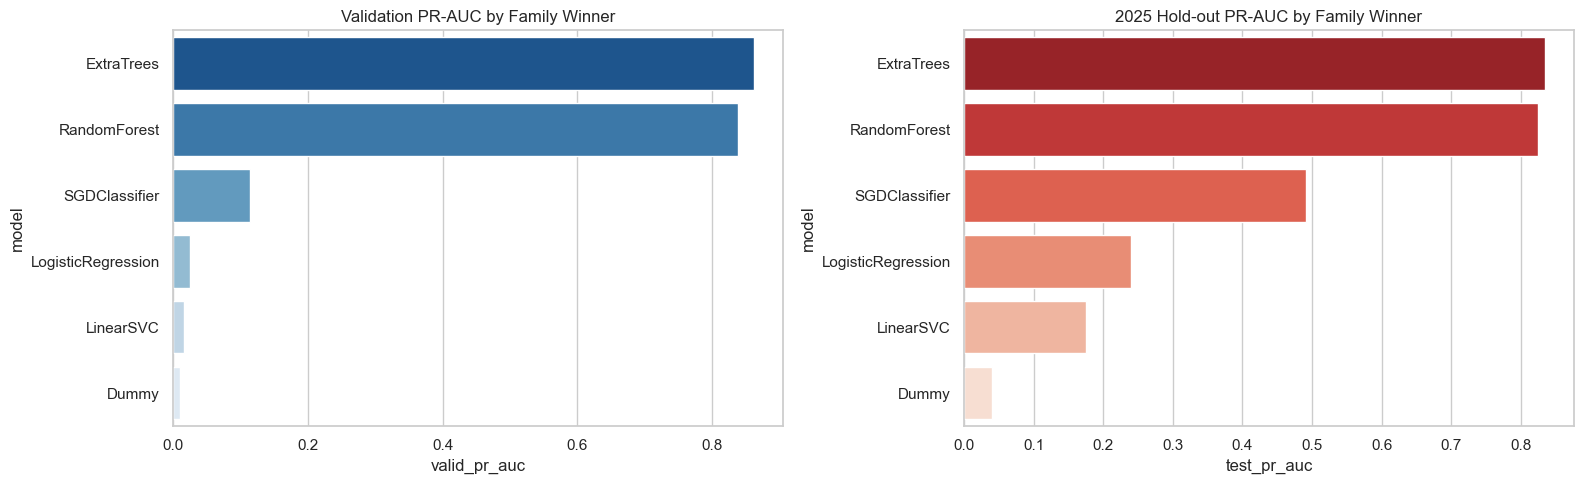

In [80]:
family_best_df = pd.DataFrame(family_best_rows)
summary_columns = [
    "model",
    "best_config",
    "score_type",
    "valid_pr_auc",
    "valid_roc_auc",
    "test_pr_auc",
    "test_roc_auc",
    "valid_brier",
    "valid_ece",
    "test_brier",
    "test_ece",
]
family_best_df = family_best_df[summary_columns].sort_values(["valid_pr_auc", "test_pr_auc"], ascending=False).reset_index(drop=True)
display(family_best_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=family_best_df, y="model", x="valid_pr_auc", palette="Blues_r", ax=axes[0])
axes[0].set_title("Validation PR-AUC by Family Winner")
sns.barplot(data=family_best_df, y="model", x="test_pr_auc", palette="Reds_r", ax=axes[1])
axes[1].set_title("2025 Hold-out PR-AUC by Family Winner")
plt.tight_layout()
plt.show()


## 8. Rolling Time-Series Backtest

This section checks the best chosen model configurations across several time-based validation folds on the training dataset. It is done because one single validation split may not represent the full year properly. This tests whether the model ranking stays stable across different time periods.


In [81]:
X_all = train_model[feature_columns]
y_all = train_model[TARGET].astype(int).to_numpy()
dates_all = train_model["tx_datetime"].reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=4)


In [82]:
backtest_rows = []
for model_name, spec in family_best_specs.items():
    estimator = spec["estimator"]
    model_type = spec["model_type"]
    for fold, (bt_train_idx, bt_valid_idx) in enumerate(tscv.split(X_all), start=1):
        pipeline = build_pipeline(estimator, model_type)
        pipeline.fit(X_all.iloc[bt_train_idx], y_all[bt_train_idx])
        fold_scores, _ = get_scores(pipeline, X_all.iloc[bt_valid_idx])
        backtest_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "valid_start": dates_all.iloc[bt_valid_idx].min(),
                "valid_end": dates_all.iloc[bt_valid_idx].max(),
                "valid_fraud_rate": y_all[bt_valid_idx].mean(),
                "pr_auc": average_precision_score(y_all[bt_valid_idx], fold_scores),
                "roc_auc": roc_auc_score(y_all[bt_valid_idx], fold_scores),
            }
        )
backtest_df = pd.DataFrame(backtest_rows)
backtest_summary = (
    backtest_df.groupby("model")
    .agg(mean_pr_auc=("pr_auc", "mean"), std_pr_auc=("pr_auc", "std"), mean_roc_auc=("roc_auc", "mean"), std_roc_auc=("roc_auc", "std"))
    .reset_index()
    .sort_values(["mean_pr_auc", "mean_roc_auc"], ascending=False)
)
display(backtest_summary)


,model,mean_pr_auc,std_pr_auc,mean_roc_auc,std_roc_auc
1,ExtraTrees,0.6941,0.1694,0.9355,0.0711
4,RandomForest,0.6659,0.1632,0.9242,0.0747
5,SGDClassifier,0.1577,0.1477,0.7730,0.0440
3,LogisticRegression,0.1099,0.1447,0.6640,0.1127
2,LinearSVC,0.0836,0.1099,0.6193,0.0875
0,Dummy,0.0175,0.0053,0.5000,0.0000


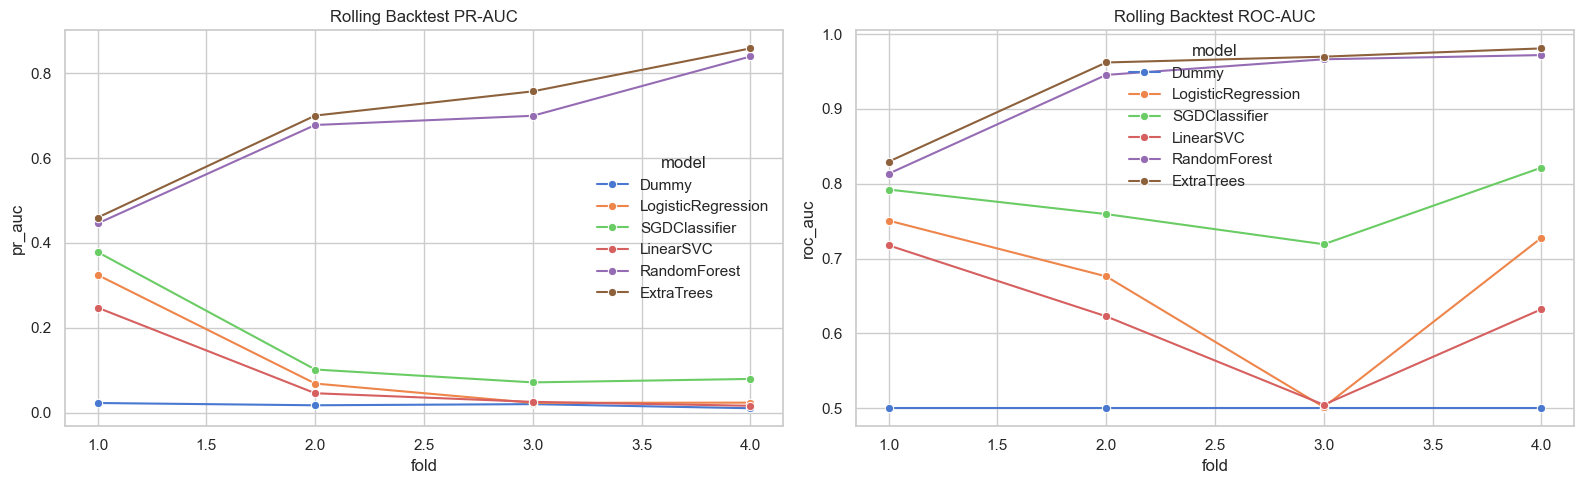

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=backtest_df, x="fold", y="pr_auc", hue="model", marker="o", ax=axes[0])
axes[0].set_title("Rolling Backtest PR-AUC")
sns.lineplot(data=backtest_df, x="fold", y="roc_auc", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Rolling Backtest ROC-AUC")
plt.tight_layout()
plt.show()


## 9. Threshold Selection and Operational Trade-offs

This section explains how the final model is turned into practical fraud alerts.
The model gives each transaction a fraud risk score. Based on that score, the system chooses which transactions should be flagged for review.


In [84]:
selected_model_name = family_best_df.iloc[0]["model"]
selected_pipeline = family_best_models[selected_model_name]
selected_valid_scores = family_best_scores[selected_model_name]["valid"]
selected_test_scores = family_best_scores[selected_model_name]["test"]


def topk_metrics(y_true, scores, frac):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(1, int(len(scores) * frac))
    order = np.argsort(scores)[::-1][:k]
    pred = np.zeros(len(scores), dtype=int)
    pred[order] = 1
    return {
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "alert_rate": pred.mean(),
    }


def threshold_metrics(y_true, scores, threshold):
    pred = (np.asarray(scores) >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "alert_rate": pred.mean(),
    }


,budget,validation_threshold,val_rank_precision,val_rank_recall,test_rank_precision,test_rank_recall,val_frozen_precision,val_frozen_recall,test_frozen_precision,test_frozen_recall,test_frozen_f1,test_frozen_alert_rate
0,0.0100,0.7251,0.8295,0.8093,1.0000,0.2500,0.8286,0.8093,0.7437,0.7616,0.7525,0.0409
1,0.0200,0.5607,0.4506,0.8792,0.9667,0.4838,0.4504,0.8792,0.4813,0.8722,0.6203,0.0724
2,0.0500,0.4157,0.1897,0.9258,0.6469,0.8093,0.1897,0.9258,0.3098,0.9444,0.4666,0.1218


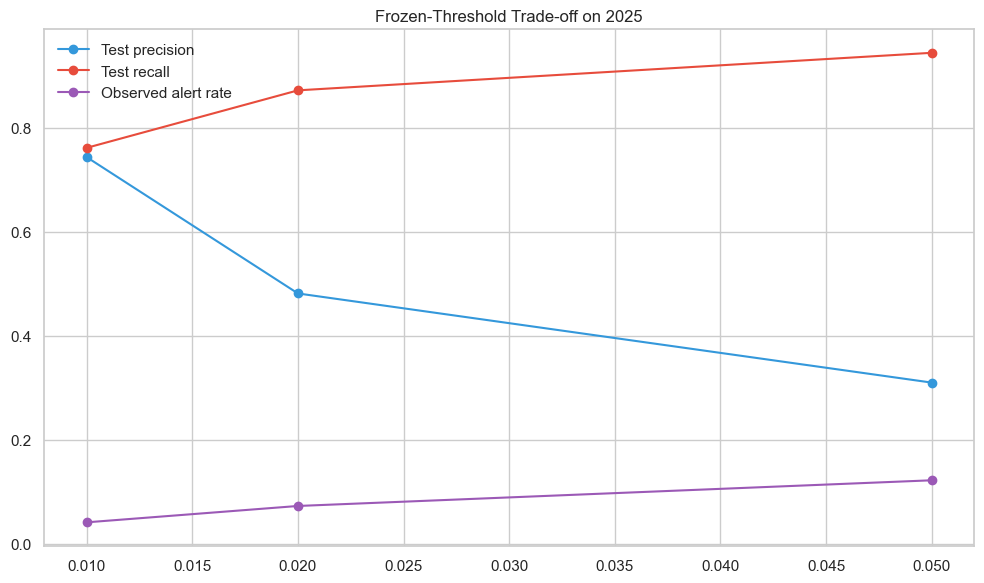

In [85]:
budget_rows = []
for budget in [0.01, 0.02, 0.05]:
    threshold = float(np.quantile(selected_valid_scores, 1 - budget))
    valid_rank = topk_metrics(y_valid, selected_valid_scores, budget)
    test_rank = topk_metrics(y_test, selected_test_scores, budget)
    valid_frozen = threshold_metrics(y_valid, selected_valid_scores, threshold)
    test_frozen = threshold_metrics(y_test, selected_test_scores, threshold)
    budget_rows.append(
        {
            "budget": budget,
            "validation_threshold": threshold,
            "val_rank_precision": valid_rank["precision"],
            "val_rank_recall": valid_rank["recall"],
            "test_rank_precision": test_rank["precision"],
            "test_rank_recall": test_rank["recall"],
            "val_frozen_precision": valid_frozen["precision"],
            "val_frozen_recall": valid_frozen["recall"],
            "test_frozen_precision": test_frozen["precision"],
            "test_frozen_recall": test_frozen["recall"],
            "test_frozen_f1": test_frozen["f1"],
            "test_frozen_alert_rate": test_frozen["alert_rate"],
        }
    )
budget_df = pd.DataFrame(budget_rows)
display(budget_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(budget_df["budget"], budget_df["test_frozen_precision"], marker="o", label="Test precision", color=COLORS["primary"])
ax.plot(budget_df["budget"], budget_df["test_frozen_recall"], marker="o", label="Test recall", color=COLORS["fraud"])
ax.plot(budget_df["budget"], budget_df["test_frozen_alert_rate"], marker="o", label="Observed alert rate", color=COLORS["secondary"])
ax.set_title("Frozen-Threshold Trade-off on 2025")
ax.legend()
plt.tight_layout()
plt.show()

selected_budget = 0.01
selected_threshold = float(budget_df.loc[budget_df["budget"] == selected_budget, "validation_threshold"].iloc[0])


#### Threshold Interpretation

The reference operating point is a **1% validation budget** because it keeps the alert list selective
while still capturing a large share of fraud in the validation period. When that threshold is frozen
and transferred to 2025, the selected `ExtraTrees` model reaches precision `0.7437`, recall `0.7616`,
and F1 `0.7525`. The observed alert rate rises to `4.09%`, which is itself informative: the score
distribution shifts materially between 2024 validation and the 2025 hold-out year. That finding
strengthens the case for threshold monitoring and periodic recalibration in any real deployment.


### 9.1 Operating-Point Diagnostics

This part shows the final alert results in a more practical way.
It shows how many transactions were correctly flagged as fraud, how many fraud cases were missed, and how many normal transactions were wrongly flagged.


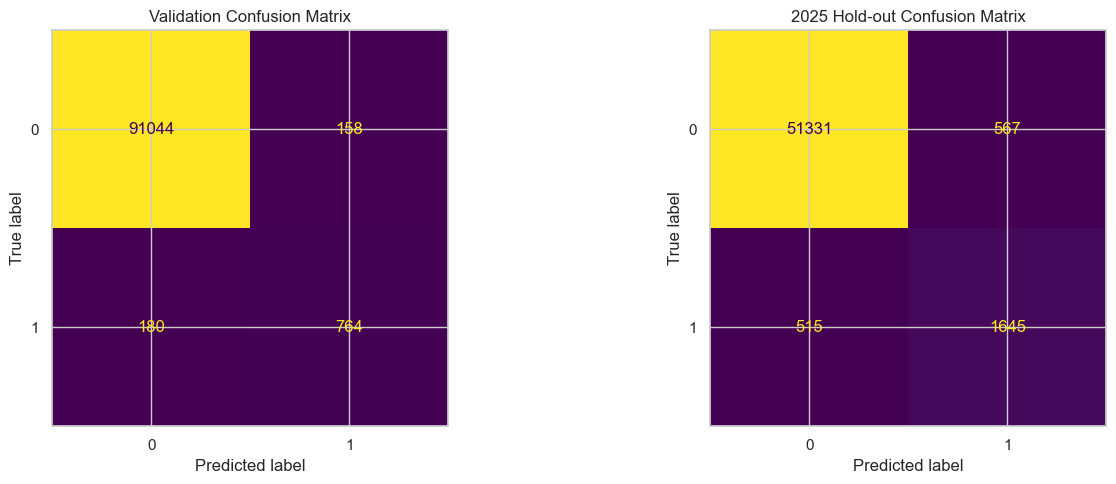

In [86]:
valid_pred = (selected_valid_scores >= selected_threshold).astype(int)
test_pred = (selected_test_scores >= selected_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_valid, valid_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Validation Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[1], colorbar=False)
axes[1].set_title("2025 Hold-out Confusion Matrix")
plt.tight_layout()
plt.show()


In [87]:
valid_eval = valid_split.copy()
valid_eval["score"] = selected_valid_scores
valid_eval["pred"] = valid_pred
test_eval = test_df.copy()
test_eval["score"] = selected_test_scores
test_eval["pred"] = test_pred


def summarize_subset(frame, name):
    return pd.Series(
        {
            "rows": len(frame),
            "fraud_rate": frame[TARGET].mean() if len(frame) else np.nan,
            "median_amount": frame["amt"].median() if len(frame) else np.nan,
            "share_night": frame["is_night"].mean() if len(frame) else np.nan,
        },
        name=name,
    )


In [88]:
test_tp = test_eval[(test_eval["pred"] == 1) & (test_eval[TARGET] == 1)]
test_fp = test_eval[(test_eval["pred"] == 1) & (test_eval[TARGET] == 0)]
test_fn = test_eval[(test_eval["pred"] == 0) & (test_eval[TARGET] == 1)]

test_error_profile = pd.concat(
    [
        summarize_subset(test_tp, "Test true positives"),
        summarize_subset(test_fp, "Test false positives"),
        summarize_subset(test_fn, "Test false negatives"),
    ],
    axis=1,
).T

test_error_categories = pd.concat(
    {
        "True positives": test_tp["category"].value_counts(normalize=True).head(5),
        "False positives": test_fp["category"].value_counts(normalize=True).head(5),
        "False negatives": test_fn["category"].value_counts(normalize=True).head(5),
    },
    axis=1,
).fillna(0)

display(test_error_profile)
display(test_error_categories)


,rows,fraud_rate,median_amount,share_night
Test true positives,"1,645.0000",1.0000,779.1700,0.9131
Test false positives,567.0000,0.0000,21.6000,0.9400
Test false negatives,515.0000,1.0000,12.7200,0.6252


,True positives,False positives,False negatives
category,,,
shopping_net,0.2778,0.1093,0.1165
grocery_pos,0.2176,0.0000,0.2971
misc_net,0.1350,0.0000,0.0951
shopping_pos,0.1228,0.1481,0.0660
gas_transport,0.0638,0.0000,0.1573
home,0.0000,0.1623,0.0000
health_fitness,0.0000,0.1270,0.0000
kids_pets,0.0000,0.1252,0.0000


#### Error-Profile Interpretation

The 2025 error analysis shows that the model is especially strong on **large, clearly risky nighttime
events**. True positives have a median amount of about `779.17` and occur at night roughly `91.3%` of
the time. False negatives are much smaller, with median amount about `12.72`, and are less
night-concentrated (`62.5%`). False positives are also heavily night-skewed (`94.0%`) but have a low
median amount (`21.60`), suggesting that the chosen threshold sometimes overreacts to night behavior
when the transaction amount is modest. This is a useful operational insight: the remaining misses are
not random, but are concentrated in subtler fraud cases.


## 10. Permutation Importance and Final Feature Interpretation

This section explains which features are most important for the final model.
It does this by changing one feature at a time and checking how much the model performance drops.


In [89]:
permutation_sample = pd.concat(
    [
        valid_split[valid_split[TARGET] == 1],
        valid_split[valid_split[TARGET] == 0].sample(n=20_000, random_state=SEED),
    ]
).sample(frac=1, random_state=SEED)


In [90]:
permutation_result = permutation_importance(
    selected_pipeline,
    permutation_sample[feature_columns],
    permutation_sample[TARGET].astype(int),
    scoring="average_precision",
    n_repeats=5,
    random_state=SEED,
    n_jobs=1,
)

permutation_df = pd.DataFrame(
    {
        "feature": permutation_sample[feature_columns].columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(permutation_df.head(15))


,feature,importance_mean,importance_std
16,high_amt_flag,0.2355,0.0032
1,amt_log,0.0686,0.0055
12,is_night,0.0496,0.0019
7,tx_hour,0.0469,0.0024
13,hour_sin,0.0227,0.0005
0,amt,0.0190,0.0014
15,online_flag,0.0176,0.0007
20,category,0.0164,0.0016
22,life_stage,0.0149,0.0019
18,gender,0.0138,0.0009


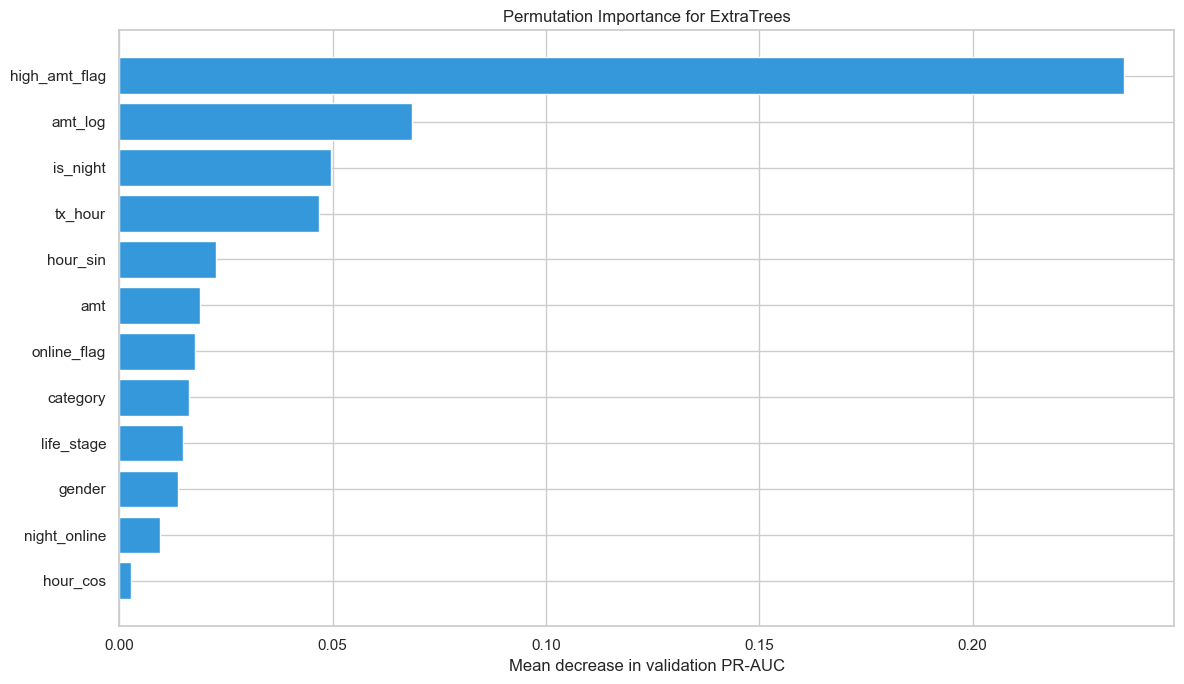

In [91]:
fig, ax = plt.subplots(figsize=(12, 7))
top_perm = permutation_df.head(12).sort_values("importance_mean")
ax.barh(top_perm["feature"], top_perm["importance_mean"], color=COLORS["primary"])
ax.set_title(f"Permutation Importance for {selected_model_name}")
ax.set_xlabel("Mean decrease in validation PR-AUC")
plt.tight_layout()
plt.show()


#### Interpretation

The importance results reinforce the EDA story almost exactly. The dominant feature is
`high_amt_flag` (`0.2355` mean PR-AUC decrease when permuted), followed by `amt_log`, `is_night`,
`tx_hour`, and then channel and category information. This is strong evidence that the winning model
is relying on the same behavioral signals uncovered earlier: large amounts, late-night timing, and
transaction context. Demographic features such as `gender` appear, but at a clearly lower importance
level than amount and timing. In thesis terms, those demographic variables are descriptive correlates,
not the central engine of predictive performance.


## 11. Exported Tables and Reproducible Artifacts

- **What this does:** Writes the comparison tables, backtest results, threshold trade-offs, permutation importance, and per-family configuration tables to disk.
- **Why it is done:** A thesis notebook should leave behind reusable artifacts that can be cited in the written report without recomputing every result.


In [92]:
family_best_df.to_csv(ARTIFACT_DIR / "family_winner_comparison.csv", index=False)
backtest_df.to_csv(ARTIFACT_DIR / "backtest_fold_results.csv", index=False)
backtest_summary.to_csv(ARTIFACT_DIR / "backtest_summary.csv", index=False)
budget_df.to_csv(ARTIFACT_DIR / "budget_tradeoffs.csv", index=False)
permutation_df.to_csv(ARTIFACT_DIR / "permutation_importance.csv", index=False)

for family_name, table in family_config_tables.items():
    safe_name = family_name.lower().replace(" ", "_")
    table.to_csv(ARTIFACT_DIR / f"{safe_name}_configs.csv", index=False)

print(f"Artifacts saved to: {ARTIFACT_DIR.resolve()}")


Artifacts saved to: /Users/nolinjo/Desktop/Thesis/artifacts/thesis_v14


## 12. Conclusion and Thesis Takeaways

This notebook keeps the original loading and core EDA flow from `Thesis-2 v7.ipynb`, adds the later
data stories, and organizes the modeling section into a clearer thesis narrative. The main conclusions
are:

- The 2025 test year is a genuine generalization problem: it has **higher fraud prevalence** and
  **zero account overlap** with the 2024 development year.
- The strongest descriptive fraud signals are transaction **amount**, **time of day**, **channel**,
  and **merchant category**. Gender and residence differences appear descriptively, but they are
  secondary and should not be interpreted causally.
- Under a validation-driven model-selection rule, `ExtraTrees` with configuration `et_medium` is the
  final thesis winner. It outperforms the linear families by a very large margin, which indicates that
  fraud in this dataset is fundamentally **nonlinear and interaction-heavy**.
- The threshold analysis shows that strong ranking performance does not eliminate the need for
  monitoring. Because the 2025 score distribution differs from late 2024, alert budgets and
  calibration should be reviewed over time in any production extension of this work.

Overall, the modeling and the descriptive analysis point to the same thesis conclusion: fraud is best
detected here by combining temporal behavior, amount-related risk, and transaction context in a
nonlinear model rather than relying on simple linear rules.
